<a href="https://colab.research.google.com/github/OJB-Quantum/QC-Hardware-How-To/blob/main/Jupyter%20Notebook%20Scripts/Coupled_Meander_CPW_Resonator_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [1]:
!uv pip install --system -q phidl matplotlib gdstk

Generated continuous right-facing meander-coupled CPW layout.
CPW trace width: 10.000 um
CPW gap width: 5.000 um
Full drawn CPW width: 20.000 um
Straight resonator length: 720.000 um
Meander side: below
Meander parallel shift: 0.000 um
Coupling edge-to-edge spacing: 12.000 um
Right-facing coupling arm length: 180.000 um
Meander run length: 170.000 um
Meander run count below coupling arm: 5
Device bounding box in micrometers: [[   0. -642.]
 [ 720.   10.]]


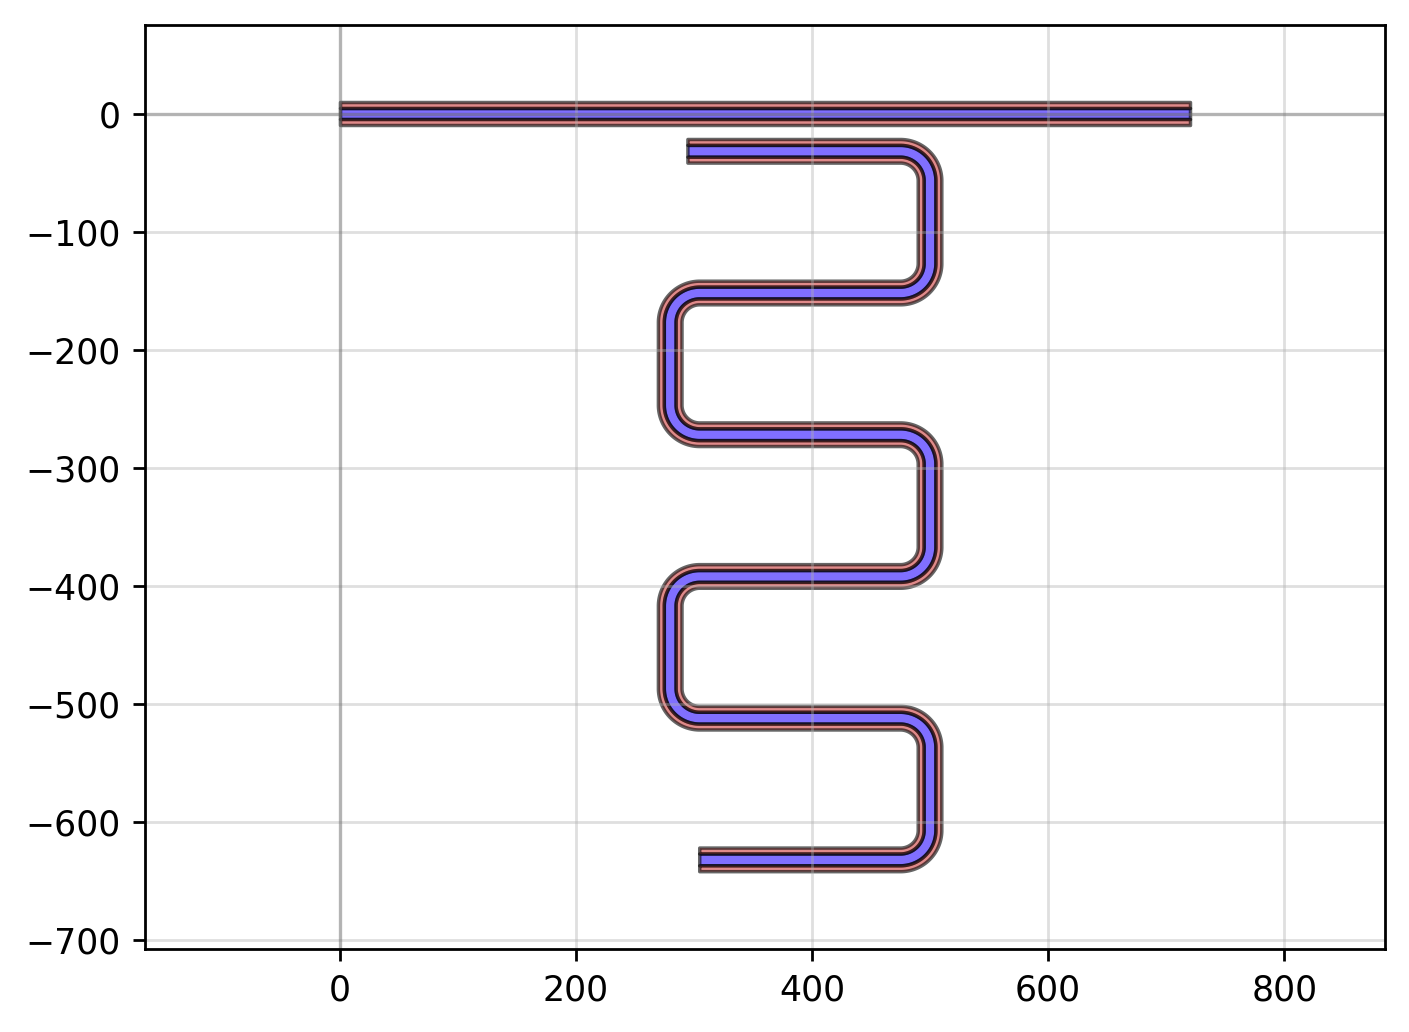

In [2]:
"""
Generate a right-facing meander CPW coupled to a straight-line CPW resonator.

This script synthesizes a PHIDL/GDSII layout containing a straight CPW
resonator and a nearby meandering CPW. The top arm of the meander runs
parallel to the straight CPW and extends to the right. Its first bend occurs
at the right end of the coupling arm, so the coupling section is a continuous
part of the serpentine geometry.

All geometry dimensions are expressed in micrometers, which is the standard
coordinate scale used for GDSII mask layout workflows.

Optional Colab install command:
    !uv pip install -q phidl gdstk matplotlib
"""

from dataclasses import dataclass
from pathlib import Path as FilePath
from typing import Literal

import gdstk
import matplotlib as mpl
import matplotlib.pyplot as plt
import phidl.path as pp
from phidl import CrossSection, Device, quickplot


# =============================================================================
# CONTROL KNOBS
# =============================================================================

# CPW transverse geometry, in micrometers.
CPW_TRACE_WIDTH_UM = 10.0
CPW_GAP_WIDTH_UM = 5.0

# Straight-line CPW resonator geometry, in micrometers.
STRAIGHT_RESONATOR_LENGTH_UM = 720.0
STRAIGHT_RESONATOR_X_ORIGIN_UM = 0.0
STRAIGHT_RESONATOR_Y_ORIGIN_UM = 0.0

# Meander placement controls, in micrometers.
# The meander coupling arm is centered on the straight resonator, then shifted.
# Positive values shift the meander to the right.
MEANDER_PARALLEL_SHIFT_UM = 0.0

# Edge-to-edge spacing between the full drawn CPW envelopes.
COUPLING_EDGE_TO_EDGE_SPACING_UM = 12.0

# Meander CPW centerline geometry, in micrometers.
# This is the right-facing capacitively coupled elbow arm.
MEANDER_COUPLING_ARM_LENGTH_UM = 180.0

# The lower meander runs follow after the first right-end turn.
MEANDER_ELBOW_BEND_RADIUS_UM = 25.0
MEANDER_VERTICAL_DROP_AFTER_COUPLER_UM = 70.0
MEANDER_RUN_LENGTH_UM = 170.0
MEANDER_RUN_COUNT = 5
MEANDER_VERTICAL_CONNECTOR_LENGTH_UM = 70.0

# Place the meander below or above the straight resonator.
MEANDER_SIDE: Literal["above", "below"] = "below"

# GDS layers.
LAYER_TRACE = 1
LAYER_GAP = 2

# Plot settings.
PLOT_DPI = 250
FONT_SANS_SERIF = ["Tahoma", "DejaVu Sans"]
FONT_WEIGHT = "normal"

# Device names.
TOP_LEVEL_DEVICE_NAME = "Continuous_Right_Facing_Meander_CPW_Coupler"
MEANDER_DEVICE_NAME = "Continuous_Right_Facing_Meander_CPW"
STRAIGHT_DEVICE_NAME = "Straight_Line_CPW_Resonator"

# Optional GDS export settings.
WRITE_GDS = False
VALIDATE_GDS_WITH_GDSTK = True
GDS_OUTPUT_PATH = FilePath("continuous_right_facing_meander_cpw_coupler.gds")


@dataclass(frozen=True)
class CpwGeometry:
    """Coplanar waveguide transverse geometry in micrometers."""

    trace_width_um: float
    gap_width_um: float
    trace_layer: int
    gap_layer: int

    @property
    def full_width_um(self) -> float:
        """Return the full drawn CPW width, including both slot gaps."""
        return self.trace_width_um + 2.0 * self.gap_width_um


@dataclass(frozen=True)
class StraightResonatorGeometry:
    """Straight CPW resonator centerline geometry and placement."""

    length_um: float
    x_origin_um: float
    y_origin_um: float


@dataclass(frozen=True)
class MeanderGeometry:
    """Meander CPW centerline geometry and placement controls."""

    parallel_shift_um: float
    coupling_edge_to_edge_spacing_um: float
    coupling_arm_length_um: float
    elbow_bend_radius_um: float
    vertical_drop_after_coupler_um: float
    run_length_um: float
    run_count: int
    vertical_connector_length_um: float
    side: Literal["above", "below"]


def configure_matplotlib() -> None:
    """Configure Matplotlib for high-resolution rendering."""
    mpl.rcParams["figure.dpi"] = PLOT_DPI
    mpl.rcParams["font.sans-serif"] = FONT_SANS_SERIF
    mpl.rcParams["font.weight"] = FONT_WEIGHT


def validate_positive_value(name: str, value: float) -> None:
    """Raise a ValueError when a dimensional control value is nonpositive."""
    if value <= 0.0:
        raise ValueError(f"{name} must be positive. Received {value}.")


def validate_zero_or_positive_value(name: str, value: float) -> None:
    """Raise a ValueError when a spacing value is below zero."""
    if value < 0.0:
        raise ValueError(f"{name} must be zero or positive. Received {value}.")


def validate_geometry(
    cpw: CpwGeometry,
    straight: StraightResonatorGeometry,
    meander: MeanderGeometry,
) -> None:
    """Validate all dimensional controls before layout generation."""
    validate_positive_value("CPW_TRACE_WIDTH_UM", cpw.trace_width_um)
    validate_positive_value("CPW_GAP_WIDTH_UM", cpw.gap_width_um)
    validate_positive_value(
        "STRAIGHT_RESONATOR_LENGTH_UM",
        straight.length_um,
    )
    validate_positive_value(
        "MEANDER_COUPLING_ARM_LENGTH_UM",
        meander.coupling_arm_length_um,
    )
    validate_positive_value(
        "MEANDER_ELBOW_BEND_RADIUS_UM",
        meander.elbow_bend_radius_um,
    )
    validate_positive_value(
        "MEANDER_VERTICAL_DROP_AFTER_COUPLER_UM",
        meander.vertical_drop_after_coupler_um,
    )
    validate_positive_value(
        "MEANDER_RUN_LENGTH_UM",
        meander.run_length_um,
    )
    validate_positive_value(
        "MEANDER_VERTICAL_CONNECTOR_LENGTH_UM",
        meander.vertical_connector_length_um,
    )
    validate_zero_or_positive_value(
        "COUPLING_EDGE_TO_EDGE_SPACING_UM",
        meander.coupling_edge_to_edge_spacing_um,
    )

    if meander.run_count < 1:
        raise ValueError(
            "MEANDER_RUN_COUNT must be at least 1. "
            f"Received {meander.run_count}."
        )


def build_cpw_cross_section(cpw: CpwGeometry) -> CrossSection:
    """
    Build a three-strip CPW drawing cross section.

    The center strip represents the signal trace. The two offset strips
    represent slot-gap regions on a separate layer for downstream Boolean
    processing or electromagnetic preprocessing.
    """
    half_trace_width_um = cpw.trace_width_um / 2.0
    half_gap_width_um = cpw.gap_width_um / 2.0
    gap_offset_um = half_trace_width_um + half_gap_width_um

    cross_section = CrossSection()
    cross_section.add(
        width=cpw.trace_width_um,
        offset=0.0,
        layer=cpw.trace_layer,
    )
    cross_section.add(
        width=cpw.gap_width_um,
        offset=gap_offset_um,
        layer=cpw.gap_layer,
    )
    cross_section.add(
        width=cpw.gap_width_um,
        offset=-gap_offset_um,
        layer=cpw.gap_layer,
    )

    return cross_section


def get_side_sign(side: Literal["above", "below"]) -> float:
    """Return the signed vertical direction of the meander."""
    if side == "above":
        return 1.0

    return -1.0


def get_turn_angle_degrees(
    horizontal_index: int,
    side: Literal["above", "below"],
) -> float:
    """
    Return the signed turn angle for a continuous serpentine meander.

    The first horizontal segment is the right-facing coupling arm. For a
    below-side meander, the first turn is clockwise at the right end of the
    coupling arm, which sends the path downward and then back left.
    """
    side_sign = get_side_sign(side)

    if horizontal_index % 2 == 0:
        return 90.0 * side_sign

    return -90.0 * side_sign


def build_straight_resonator(
    cross_section: CrossSection,
    straight: StraightResonatorGeometry,
) -> Device:
    """Create a straight-line CPW resonator path."""
    straight_path = pp.Path()
    straight_path.append(pp.straight(length=straight.length_um))

    straight_device = straight_path.extrude(cross_section)
    straight_device.name = STRAIGHT_DEVICE_NAME

    return straight_device


def build_meander_cpw(
    cross_section: CrossSection,
    meander: MeanderGeometry,
) -> Device:
    """
    Create a continuous right-facing meandering CPW.

    The path begins with a right-facing capacitive coupling arm, bends at the
    right end of that arm, and continues into alternating serpentine runs.
    """
    path = pp.Path()
    horizontal_segment_count = meander.run_count + 1

    for horizontal_index in range(horizontal_segment_count):
        if horizontal_index == 0:
            segment_length_um = meander.coupling_arm_length_um
        else:
            segment_length_um = meander.run_length_um

        path.append(pp.straight(length=segment_length_um))

        if horizontal_index < horizontal_segment_count - 1:
            turn_angle_degrees = get_turn_angle_degrees(
                horizontal_index=horizontal_index,
                side=meander.side,
            )

            if horizontal_index == 0:
                vertical_length_um = meander.vertical_drop_after_coupler_um
            else:
                vertical_length_um = meander.vertical_connector_length_um

            path.append(
                pp.arc(
                    radius=meander.elbow_bend_radius_um,
                    angle=turn_angle_degrees,
                )
            )
            path.append(pp.straight(length=vertical_length_um))
            path.append(
                pp.arc(
                    radius=meander.elbow_bend_radius_um,
                    angle=turn_angle_degrees,
                )
            )

    meander_device = path.extrude(cross_section)
    meander_device.name = MEANDER_DEVICE_NAME

    return meander_device


def get_coupling_arm_start_x(
    straight: StraightResonatorGeometry,
    meander: MeanderGeometry,
) -> float:
    """Return the target x-start of the meander coupling arm."""
    straight_center_x_um = straight.x_origin_um + 0.5 * straight.length_um
    coupling_center_x_um = straight_center_x_um + meander.parallel_shift_um

    return coupling_center_x_um - 0.5 * meander.coupling_arm_length_um


def align_meander_x_position(
    meander_reference,
    straight: StraightResonatorGeometry,
    meander: MeanderGeometry,
) -> None:
    """
    Align the coupling arm along the straight resonator.

    The generated path starts at the left end of the right-facing coupling arm,
    so the meander reference x-min is assigned to the target coupling-arm start.
    """
    meander_reference.xmin = get_coupling_arm_start_x(
        straight=straight,
        meander=meander,
    )


def align_meander_y_position(
    straight_reference,
    meander_reference,
    meander: MeanderGeometry,
) -> None:
    """
    Place the meander next to the straight CPW by full-envelope edge spacing.
    """
    spacing_um = meander.coupling_edge_to_edge_spacing_um

    if meander.side == "above":
        meander_reference.ymin = straight_reference.ymax + spacing_um
    else:
        meander_reference.ymax = straight_reference.ymin - spacing_um


def assemble_meander_coupled_circuit(
    cpw: CpwGeometry,
    straight: StraightResonatorGeometry,
    meander: MeanderGeometry,
) -> Device:
    """
    Assemble the straight CPW and the automatically placed meander CPW.
    """
    validate_geometry(cpw=cpw, straight=straight, meander=meander)

    cross_section = build_cpw_cross_section(cpw=cpw)
    straight_device = build_straight_resonator(
        cross_section=cross_section,
        straight=straight,
    )
    meander_device = build_meander_cpw(
        cross_section=cross_section,
        meander=meander,
    )

    top_level_device = Device(name=TOP_LEVEL_DEVICE_NAME)
    straight_reference = top_level_device << straight_device
    meander_reference = top_level_device << meander_device

    straight_reference.xmin = straight.x_origin_um
    straight_reference.y = straight.y_origin_um

    align_meander_x_position(
        meander_reference=meander_reference,
        straight=straight,
        meander=meander,
    )
    align_meander_y_position(
        straight_reference=straight_reference,
        meander_reference=meander_reference,
        meander=meander,
    )

    return top_level_device


def write_gds_file(device: Device, output_path: FilePath) -> None:
    """Write the PHIDL device to a GDSII file."""
    device.write_gds(str(output_path))
    print(f"Wrote GDS file: {output_path}")


def validate_gds_file_with_gdstk(gds_path: FilePath) -> None:
    """Read an exported GDSII file with GDSTK and print a compact summary."""
    library = gdstk.read_gds(str(gds_path))
    top_cells = library.top_level()

    if len(top_cells) == 0:
        raise RuntimeError("GDSTK readback found zero top-level cells.")

    print("GDSTK validation passed.")
    print(f"Top-level cell count: {len(top_cells)}")

    for cell in top_cells:
        print(
            f"Cell '{cell.name}': "
            f"{len(cell.polygons)} polygons, "
            f"{len(cell.references)} references"
        )


def plot_device(device: Device) -> None:
    """Render the PHIDL device directly in the output cell."""
    quickplot(device)
    plt.show()


def main() -> Device:
    """Generate, render, and optionally validate the CPW layout."""
    configure_matplotlib()

    cpw = CpwGeometry(
        trace_width_um=CPW_TRACE_WIDTH_UM,
        gap_width_um=CPW_GAP_WIDTH_UM,
        trace_layer=LAYER_TRACE,
        gap_layer=LAYER_GAP,
    )
    straight = StraightResonatorGeometry(
        length_um=STRAIGHT_RESONATOR_LENGTH_UM,
        x_origin_um=STRAIGHT_RESONATOR_X_ORIGIN_UM,
        y_origin_um=STRAIGHT_RESONATOR_Y_ORIGIN_UM,
    )
    meander = MeanderGeometry(
        parallel_shift_um=MEANDER_PARALLEL_SHIFT_UM,
        coupling_edge_to_edge_spacing_um=COUPLING_EDGE_TO_EDGE_SPACING_UM,
        coupling_arm_length_um=MEANDER_COUPLING_ARM_LENGTH_UM,
        elbow_bend_radius_um=MEANDER_ELBOW_BEND_RADIUS_UM,
        vertical_drop_after_coupler_um=MEANDER_VERTICAL_DROP_AFTER_COUPLER_UM,
        run_length_um=MEANDER_RUN_LENGTH_UM,
        run_count=MEANDER_RUN_COUNT,
        vertical_connector_length_um=MEANDER_VERTICAL_CONNECTOR_LENGTH_UM,
        side=MEANDER_SIDE,
    )

    device = assemble_meander_coupled_circuit(
        cpw=cpw,
        straight=straight,
        meander=meander,
    )

    print("Generated continuous right-facing meander-coupled CPW layout.")
    print(f"CPW trace width: {cpw.trace_width_um:.3f} um")
    print(f"CPW gap width: {cpw.gap_width_um:.3f} um")
    print(f"Full drawn CPW width: {cpw.full_width_um:.3f} um")
    print(f"Straight resonator length: {straight.length_um:.3f} um")
    print(f"Meander side: {meander.side}")
    print(f"Meander parallel shift: {meander.parallel_shift_um:.3f} um")
    print(
        "Coupling edge-to-edge spacing: "
        f"{meander.coupling_edge_to_edge_spacing_um:.3f} um"
    )
    print(
        "Right-facing coupling arm length: "
        f"{meander.coupling_arm_length_um:.3f} um"
    )
    print(f"Meander run length: {meander.run_length_um:.3f} um")
    print(f"Meander run count below coupling arm: {meander.run_count}")
    print(f"Device bounding box in micrometers: {device.bbox}")

    if WRITE_GDS:
        write_gds_file(device=device, output_path=GDS_OUTPUT_PATH)

        if VALIDATE_GDS_WITH_GDSTK:
            validate_gds_file_with_gdstk(gds_path=GDS_OUTPUT_PATH)

    plot_device(device)

    return device


if __name__ == "__main__":
    layout_device = main()

In [3]:
"""
Export the generated right-facing meander CPW layout as an OASIS file.

This cell converts an already generated PHIDL device into a temporary GDSII
file, imports that GDSII file into GDSTK, writes an OASIS file, and validates
the OASIS file by reading it back with GDSTK.

The geometry coordinate convention remains micrometers because the PHIDL layout
was generated using micrometer-scale dimensions.
"""

from __future__ import annotations

from pathlib import Path
from typing import Any


import gdstk


# =============================================================================
# CONTROL KNOBS
# =============================================================================

OASIS_OUTPUT_PATH = Path("continuous_right_facing_meander_cpw_coupler.oas")
TEMPORARY_GDS_PATH = Path(
    "continuous_right_facing_meander_cpw_coupler_temp.gds"
)

# Search order for the generated PHIDL device from the layout-generation cell.
# The most recent code block creates "layout_device" at the end.
PHIDL_DEVICE_GLOBAL_NAMES = (
    "layout_device",
    "microwave_device",
)

REMOVE_TEMPORARY_GDS = False
VALIDATE_OASIS_READBACK = True
PRINT_CELL_DETAILS = True


def get_generated_phidl_device(global_names: tuple[str, ...]) -> Any:
    """
    Find the generated PHIDL device in the notebook global namespace.

    Args:
        global_names: Candidate global variable names to search.

    Returns:
        PHIDL Device object that supports write_gds().
    """
    for global_name in global_names:
        candidate = globals().get(global_name)

        if candidate is None:
            continue

        if hasattr(candidate, "write_gds"):
            print(f"Using PHIDL device from global variable: {global_name}")
            return candidate

    searched_names = ", ".join(global_names)
    raise NameError(
        "No generated PHIDL device was found. Run the layout-generation "
        f"cell first. Searched these global names: {searched_names}."
    )


def export_phidl_device_to_oasis(
    device: Any,
    temporary_gds_path: Path,
    oasis_output_path: Path,
) -> None:
    """
    Export a PHIDL device to OASIS by converting through GDSTK.

    Args:
        device: PHIDL Device object to export.
        temporary_gds_path: Temporary GDSII path used for PHIDL-to-GDSTK
            transfer.
        oasis_output_path: Final OASIS output path.
    """
    device.write_gds(str(temporary_gds_path))

    gdstk_library = gdstk.read_gds(str(temporary_gds_path))
    gdstk_library.write_oas(str(oasis_output_path))

    print(f"Wrote temporary GDSII file: {temporary_gds_path}")
    print(f"Wrote OASIS file: {oasis_output_path}")


def validate_oasis_file(
    oasis_output_path: Path,
    print_cell_details: bool,
) -> None:
    """
    Validate an OASIS file by reading it back with GDSTK.

    Args:
        oasis_output_path: OASIS file path to validate.
        print_cell_details: Whether to print polygon and reference counts for
            each top-level cell.
    """
    gdstk_library = gdstk.read_oas(str(oasis_output_path))
    top_cells = gdstk_library.top_level()

    if len(top_cells) == 0:
        raise RuntimeError("OASIS readback found zero top-level cells.")

    print("OASIS readback validation passed.")
    print(f"Top-level cell count: {len(top_cells)}")

    if print_cell_details:
        for cell in top_cells:
            print(
                f"Cell '{cell.name}': "
                f"{len(cell.polygons)} polygons, "
                f"{len(cell.references)} references"
            )


def remove_temporary_gds_file(temporary_gds_path: Path) -> None:
    """
    Remove the temporary GDSII file when requested.

    Args:
        temporary_gds_path: Temporary GDSII path to remove.
    """
    if temporary_gds_path.exists():
        temporary_gds_path.unlink()
        print(f"Removed temporary GDSII file: {temporary_gds_path}")


def main() -> None:
    """Export the generated microwave layout to OASIS."""
    phidl_device = get_generated_phidl_device(
        global_names=PHIDL_DEVICE_GLOBAL_NAMES,
    )

    export_phidl_device_to_oasis(
        device=phidl_device,
        temporary_gds_path=TEMPORARY_GDS_PATH,
        oasis_output_path=OASIS_OUTPUT_PATH,
    )

    if VALIDATE_OASIS_READBACK:
        validate_oasis_file(
            oasis_output_path=OASIS_OUTPUT_PATH,
            print_cell_details=PRINT_CELL_DETAILS,
        )

    if REMOVE_TEMPORARY_GDS:
        remove_temporary_gds_file(
            temporary_gds_path=TEMPORARY_GDS_PATH,
        )


if __name__ == "__main__":
    main()

Using PHIDL device from global variable: layout_device
Wrote temporary GDSII file: continuous_right_facing_meander_cpw_coupler_temp.gds
Wrote OASIS file: continuous_right_facing_meander_cpw_coupler.oas
OASIS readback validation passed.
Top-level cell count: 1
Cell 'toplevel': 0 polygons, 2 references


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Using PHIDL device from global variable: layout_device
Preview filtering backend: CuPy/T4
Source polygons: 6
Ground box width: 790.000 um
Ground box height: 790.000 um
Trace metal surfaces meshed: False
Gap outer edges embedded: False


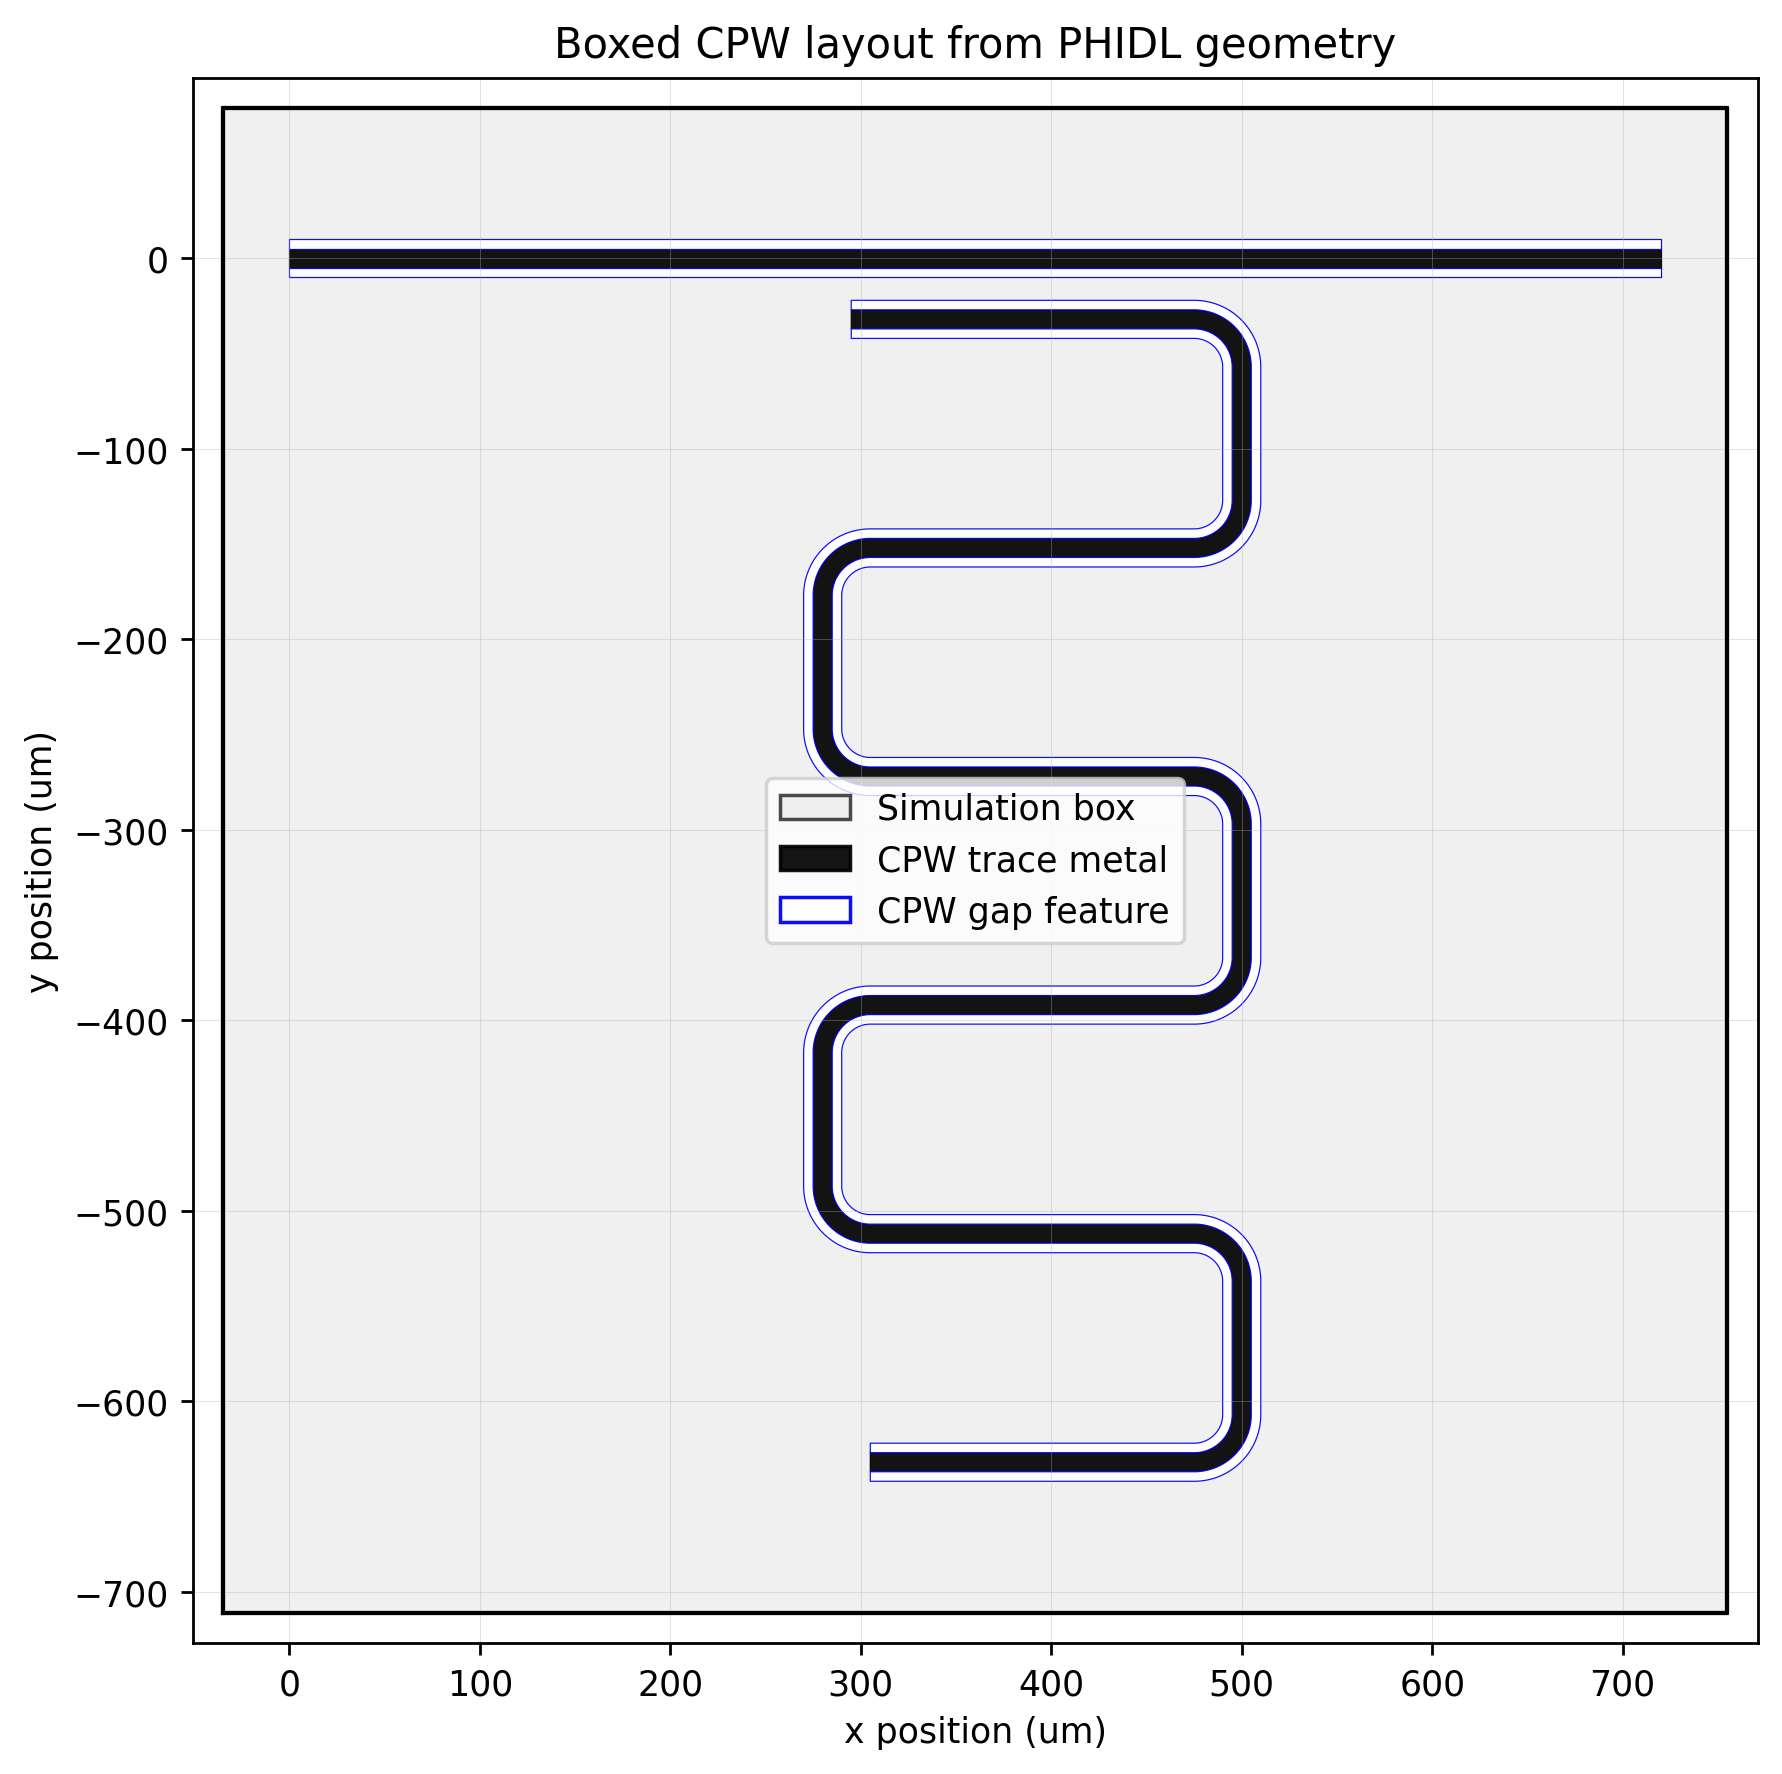

Generated clean boxed Gmsh adaptive mesh.
Mesh generation and extraction time: 2.63 s
Mesh nodes: 26,978
Mesh triangles: 45,338
Trace metal surfaces meshed: 0
Wrote mesh file: clean_boxed_meander_cpw_gmsh_mesh.msh


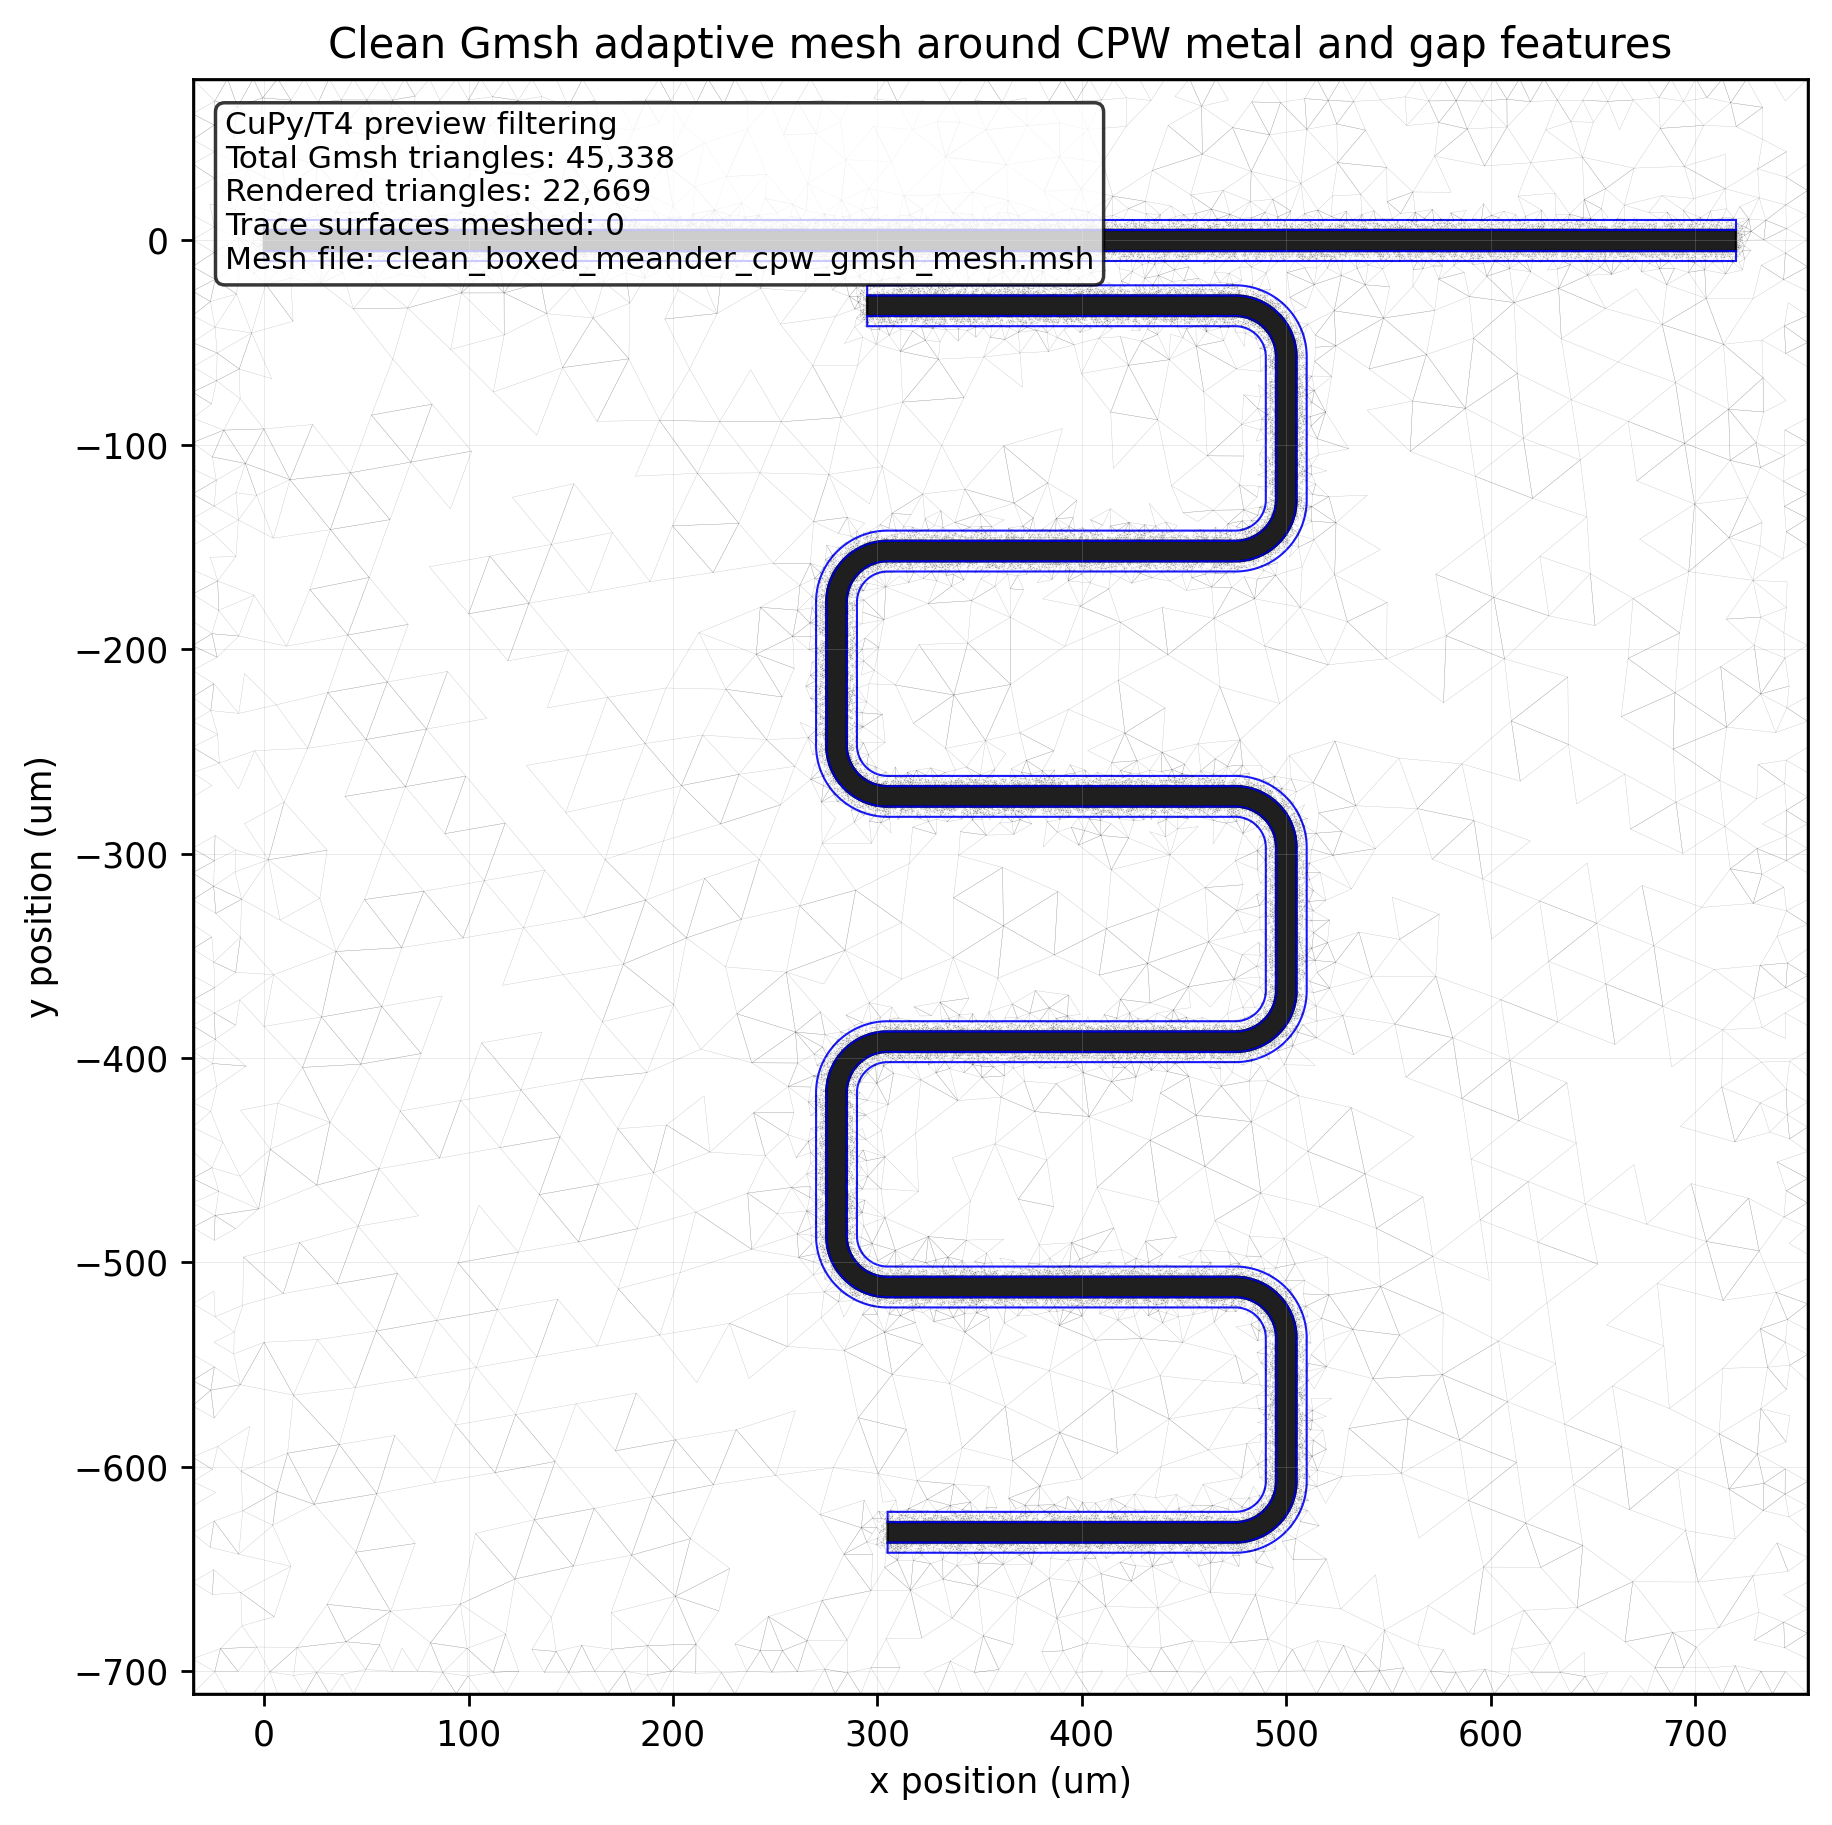

In [4]:
"""
Generate a clean boxed layout preview and Gmsh mesh render for a PHIDL CPW layout.

This Colab cell uses an existing PHIDL CPW device as the geometry source, adds
a surrounding simulation box, generates a real Gmsh triangular mesh, optionally
writes the mesh file, and renders both the boxed layout and a clean mesh
preview.

The trace polygons are treated as metal holes in the dielectric mesh. This
avoids rendering dense triangles inside the conductors, which can make the mesh
look visually corrupted. Gap outer edges are embedded as refinement features so
the adaptive mesh follows the CPW slots more faithfully.

Gmsh performs unstructured mesh generation on the CPU. CuPy is used only for
fast triangle filtering and preview decimation when a CUDA GPU is available.
"""

# =============================================================================
# COLAB DEPENDENCY INSTALLATION
# =============================================================================

!apt-get update -qq
!apt-get install -y -qq libglu1-mesa libgl1
!uv pip install -q numpy matplotlib cupy-cuda12x phidl gdstk gmsh

from dataclasses import dataclass
from pathlib import Path
from typing import Any

import gmsh
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection, PatchCollection
from matplotlib.patches import Patch
from matplotlib.patches import Polygon as MatplotlibPolygon


# =============================================================================
# CONTROL KNOBS
# =============================================================================

PHIDL_DEVICE_GLOBAL_NAMES = (
    "layout_device",
    "microwave_device",
)

# Layout layers from the CPW generator.
LAYER_TRACE = 1
LAYER_GAP = 2

# Box geometry, in micrometers.
GROUND_BOX_CLEARANCE_UM = 35.0
GROUND_BOX_FORCE_SQUARE = True

# Gmsh output.
WRITE_MSH_FILE = True
MESH_OUTPUT_PATH = Path("clean_boxed_meander_cpw_gmsh_mesh.msh")

# Adaptive mesh sizing, in micrometers.
FEATURE_MESH_SIZE_MIN_UM = 1.20
FEATURE_MESH_SIZE_MAX_UM = 30.00
FEATURE_REFINE_DISTANCE_MIN_UM = 2.50
FEATURE_REFINE_DISTANCE_MAX_UM = 24.00

OUTER_BOX_MESH_SIZE_MIN_UM = 12.00
OUTER_BOX_MESH_SIZE_MAX_UM = 42.00
OUTER_BOX_REFINE_DISTANCE_MIN_UM = 10.00
OUTER_BOX_REFINE_DISTANCE_MAX_UM = 55.00

DISTANCE_FIELD_SAMPLING_POINTS = 24

# Geometry fidelity controls.
# Keep this False for the preview so metal interiors are treated as holes.
MESH_TRACE_METAL_SURFACES = False

# Enable gap-edge embedding so mesh refinement follows the CPW gap layer.
EMBED_GAP_OUTER_EDGES = False # Make this False to generate the mesh faster
REMOVE_GAP_EDGES_COINCIDENT_WITH_TRACE = True
DUPLICATE_EDGE_TOLERANCE_UM = 1.0e-5

# Gmsh controls.
MESH_ALGORITHM_2D = 6
GENERAL_NUM_THREADS = 0
SUPPRESS_GMSH_OUTPUT = True
OPTIMIZE_MESH = True

# Physical group tags.
DIELECTRIC_SURFACE_PHYSICAL_TAG = 100
TRACE_SURFACE_PHYSICAL_TAG = 101
OUTER_BOUNDARY_PHYSICAL_TAG = 200
TRACE_BOUNDARY_PHYSICAL_TAG = 201
GAP_FEATURE_PHYSICAL_TAG = 202

# Rendering controls.
PLOT_DPI = 250
LAYOUT_FIGURE_SIZE = (8.6, 7.2)
MESH_FIGURE_SIZE = (9.0, 7.4)

MESH_LINE_WIDTH = 0.10
MESH_LINE_ALPHA = 0.25
MAX_RENDERED_TRIANGLES = 42_000
MESH_PREVIEW_MARGIN_FACTOR = 0.02

TRACE_PREVIEW_FILL_ALPHA = 0.88
TRACE_PREVIEW_EDGE_WIDTH = 0.70
GAP_PREVIEW_EDGE_WIDTH = 0.60

SHOW_MESH_DIAGNOSTIC_BOX = True


# =============================================================================
# DATA STRUCTURES
# =============================================================================

@dataclass(frozen=True)
class LayoutPolygon:
    """Store one PHIDL polygon."""

    points_um: np.ndarray
    layer: int
    datatype: int = 0


@dataclass(frozen=True)
class GroundBox:
    """Store surrounding box bounds in micrometers."""

    xmin_um: float
    ymin_um: float
    xmax_um: float
    ymax_um: float

    @property
    def width_um(self) -> float:
        """Return the box width."""
        return self.xmax_um - self.xmin_um

    @property
    def height_um(self) -> float:
        """Return the box height."""
        return self.ymax_um - self.ymin_um

    @property
    def points_um(self) -> np.ndarray:
        """Return counterclockwise box vertices."""
        return np.array(
            [
                [self.xmin_um, self.ymin_um],
                [self.xmax_um, self.ymin_um],
                [self.xmax_um, self.ymax_um],
                [self.xmin_um, self.ymax_um],
            ],
            dtype=float,
        )


@dataclass(frozen=True)
class GmshMesh:
    """Store extracted Gmsh mesh arrays."""

    xy_coordinates_um: np.ndarray
    triangles: np.ndarray


# =============================================================================
# GENERAL UTILITIES
# =============================================================================

def configure_matplotlib() -> None:
    """Configure Matplotlib for high-resolution Colab rendering."""
    mpl.rcParams["figure.dpi"] = PLOT_DPI

    try:
        get_ipython().run_line_magic("matplotlib", "inline")
    except NameError:
        pass


def select_array_backend() -> tuple[Any, bool]:
    """Select CuPy for preview filtering when a CUDA GPU is available."""
    try:
        import cupy as cp

        if cp.cuda.runtime.getDeviceCount() > 0:
            return cp, True
    except Exception:
        pass

    return np, False


XP, USING_CUPY = select_array_backend()


def to_numpy(array: Any) -> np.ndarray:
    """Convert a NumPy or CuPy array to NumPy."""
    if USING_CUPY:
        return XP.asnumpy(array)

    return np.asarray(array)


def get_existing_layout_device() -> Any:
    """Return the PHIDL layout generated upstream."""
    for global_name in PHIDL_DEVICE_GLOBAL_NAMES:
        candidate = globals().get(global_name)

        if candidate is None:
            continue

        if hasattr(candidate, "write_gds"):
            print(f"Using PHIDL device from global variable: {global_name}")
            return candidate

    searched_names = ", ".join(PHIDL_DEVICE_GLOBAL_NAMES)
    raise NameError(
        "No generated PHIDL device was found. Run the layout-generation "
        f"cell first. Searched these names: {searched_names}."
    )


# =============================================================================
# POLYGON EXTRACTION
# =============================================================================

def polygon_signed_area(points_um: np.ndarray) -> float:
    """Return signed polygon area in square micrometers."""
    points = np.asarray(points_um, dtype=float)
    x_values = points[:, 0]
    y_values = points[:, 1]

    return 0.5 * float(
        np.dot(x_values, np.roll(y_values, -1))
        - np.dot(y_values, np.roll(x_values, -1))
    )


def clean_polygon(points_um: np.ndarray) -> np.ndarray:
    """Remove duplicate closure points and enforce counterclockwise order."""
    points = np.asarray(points_um, dtype=float)

    if len(points) >= 2 and np.linalg.norm(points[0] - points[-1]) < 1.0e-12:
        points = points[:-1]

    if len(points) < 3:
        return np.empty((0, 2), dtype=float)

    area_um2 = polygon_signed_area(points)

    if abs(area_um2) < 1.0e-12:
        return np.empty((0, 2), dtype=float)

    if area_um2 < 0.0:
        points = points[::-1]

    return points


def extract_layout_polygons(device: Any) -> list[LayoutPolygon]:
    """Extract trace and gap polygons from the PHIDL device."""
    polygons_by_spec = device.get_polygons(by_spec=True)
    polygons: list[LayoutPolygon] = []

    for spec, point_sets in polygons_by_spec.items():
        if isinstance(spec, tuple):
            layer = int(spec[0])
            datatype = int(spec[1]) if len(spec) > 1 else 0
        else:
            layer = int(spec)
            datatype = 0

        for point_set in point_sets:
            points = clean_polygon(np.asarray(point_set, dtype=float))

            if len(points) >= 3:
                polygons.append(
                    LayoutPolygon(
                        points_um=points,
                        layer=layer,
                        datatype=datatype,
                    )
                )

    return polygons


def compute_ground_box(device: Any) -> GroundBox:
    """Compute a surrounding box from the PHIDL device bounding box."""
    bbox = np.asarray(device.bbox, dtype=float)

    xmin_um = float(bbox[0, 0])
    ymin_um = float(bbox[0, 1])
    xmax_um = float(bbox[1, 0])
    ymax_um = float(bbox[1, 1])

    center_x_um = 0.5 * (xmin_um + xmax_um)
    center_y_um = 0.5 * (ymin_um + ymax_um)

    width_um = xmax_um - xmin_um
    height_um = ymax_um - ymin_um

    if GROUND_BOX_FORCE_SQUARE:
        span_um = max(width_um, height_um) + 2.0 * GROUND_BOX_CLEARANCE_UM
        half_span_um = 0.5 * span_um

        return GroundBox(
            xmin_um=center_x_um - half_span_um,
            ymin_um=center_y_um - half_span_um,
            xmax_um=center_x_um + half_span_um,
            ymax_um=center_y_um + half_span_um,
        )

    return GroundBox(
        xmin_um=xmin_um - GROUND_BOX_CLEARANCE_UM,
        ymin_um=ymin_um - GROUND_BOX_CLEARANCE_UM,
        xmax_um=xmax_um + GROUND_BOX_CLEARANCE_UM,
        ymax_um=ymax_um + GROUND_BOX_CLEARANCE_UM,
    )


# =============================================================================
# GMSH GEOMETRY AND MESH
# =============================================================================

def polygon_segments(points_um: np.ndarray) -> np.ndarray:
    """Return closed polygon segments with shape (N, 2, 2)."""
    points = np.asarray(points_um, dtype=float)
    return np.stack([points, np.roll(points, -1, axis=0)], axis=1)


def point_segment_distances(
    points_um: np.ndarray,
    segments_um: np.ndarray,
) -> np.ndarray:
    """Return point-to-segment distances for duplicate-edge filtering."""
    points = points_um[:, None, :]
    starts = segments_um[None, :, 0, :]
    ends = segments_um[None, :, 1, :]

    segment_vectors = ends - starts
    point_vectors = points - starts

    lengths_sq = np.sum(segment_vectors**2, axis=2)
    lengths_sq = np.maximum(lengths_sq, 1.0e-30)

    projection = np.sum(point_vectors * segment_vectors, axis=2) / lengths_sq
    projection = np.clip(projection, 0.0, 1.0)

    closest = starts + projection[:, :, None] * segment_vectors
    distances = np.linalg.norm(points - closest, axis=2)

    return distances


def collect_gap_outer_segments(
    source_polygons: list[LayoutPolygon],
) -> list[tuple[np.ndarray, np.ndarray]]:
    """Collect gap edges, optionally removing edges coincident with trace."""
    trace_segment_groups = []
    gap_segment_groups = []

    for polygon in source_polygons:
        if polygon.layer == LAYER_TRACE:
            trace_segment_groups.append(polygon_segments(polygon.points_um))
        elif polygon.layer == LAYER_GAP:
            gap_segment_groups.append(polygon_segments(polygon.points_um))

    if len(gap_segment_groups) == 0:
        return []

    all_gap_segments = np.concatenate(gap_segment_groups, axis=0)

    if (
        REMOVE_GAP_EDGES_COINCIDENT_WITH_TRACE is False
        or len(trace_segment_groups) == 0
    ):
        return [(segment[0], segment[1]) for segment in all_gap_segments]

    all_trace_segments = np.concatenate(trace_segment_groups, axis=0)
    midpoints = 0.5 * (all_gap_segments[:, 0, :] + all_gap_segments[:, 1, :])
    distances = point_segment_distances(midpoints, all_trace_segments)
    min_distances = distances.min(axis=1)

    selected_segments = []
    for segment, distance_um in zip(all_gap_segments, min_distances):
        if distance_um > DUPLICATE_EDGE_TOLERANCE_UM:
            selected_segments.append((segment[0], segment[1]))

    return selected_segments


def add_polygon_loop_geo(
    points_um: np.ndarray,
    mesh_size_um: float,
) -> tuple[int, tuple[int, ...]]:
    """Add a closed polygon loop to Gmsh's built-in geometry kernel."""
    point_tags = [
        gmsh.model.geo.addPoint(float(x_um), float(y_um), 0.0, mesh_size_um)
        for x_um, y_um in points_um
    ]

    curve_tags = []
    point_count = len(point_tags)

    for index in range(point_count):
        curve_tags.append(
            gmsh.model.geo.addLine(
                point_tags[index],
                point_tags[(index + 1) % point_count],
            )
        )

    loop_tag = gmsh.model.geo.addCurveLoop(curve_tags)

    return loop_tag, tuple(curve_tags)


def add_gap_segments_geo(
    segments: list[tuple[np.ndarray, np.ndarray]],
    mesh_size_um: float,
) -> tuple[int, ...]:
    """Add selected gap outer-edge segments to Gmsh."""
    curve_tags = []

    for start_point, end_point in segments:
        start_tag = gmsh.model.geo.addPoint(
            float(start_point[0]),
            float(start_point[1]),
            0.0,
            mesh_size_um,
        )
        end_tag = gmsh.model.geo.addPoint(
            float(end_point[0]),
            float(end_point[1]),
            0.0,
            mesh_size_um,
        )
        curve_tags.append(gmsh.model.geo.addLine(start_tag, end_tag))

    return tuple(curve_tags)


def build_gmsh_geometry(
    ground_box: GroundBox,
    source_polygons: list[LayoutPolygon],
) -> tuple[int, tuple[int, ...], tuple[int, ...], tuple[int, ...]]:
    """Build a boxed Gmsh model with trace polygons as conductor holes."""
    trace_polygons = [
        polygon
        for polygon in source_polygons
        if polygon.layer == LAYER_TRACE
    ]

    outer_loop, outer_curve_tags = add_polygon_loop_geo(
        ground_box.points_um,
        OUTER_BOX_MESH_SIZE_MAX_UM,
    )

    trace_loop_tags = []
    trace_curve_tags = []

    for polygon in trace_polygons:
        loop_tag, curve_tags = add_polygon_loop_geo(
            polygon.points_um,
            FEATURE_MESH_SIZE_MIN_UM,
        )
        trace_loop_tags.append(loop_tag)
        trace_curve_tags.extend(curve_tags)

    dielectric_surface_tag = gmsh.model.geo.addPlaneSurface(
        [outer_loop] + trace_loop_tags
    )

    trace_surface_tags = []
    if MESH_TRACE_METAL_SURFACES:
        for loop_tag in trace_loop_tags:
            trace_surface_tags.append(gmsh.model.geo.addPlaneSurface([loop_tag]))

    gap_curve_tags: tuple[int, ...] = tuple()
    if EMBED_GAP_OUTER_EDGES:
        gap_segments = collect_gap_outer_segments(source_polygons)
        gap_curve_tags = add_gap_segments_geo(
            segments=gap_segments,
            mesh_size_um=FEATURE_MESH_SIZE_MIN_UM,
        )

    gmsh.model.geo.synchronize()

    if len(gap_curve_tags) > 0:
        gmsh.model.mesh.embed(
            1,
            list(gap_curve_tags),
            2,
            dielectric_surface_tag,
        )

    globals()["_LAST_TRACE_SURFACE_TAGS"] = tuple(trace_surface_tags)

    return (
        dielectric_surface_tag,
        tuple(outer_curve_tags),
        tuple(trace_curve_tags),
        tuple(gap_curve_tags),
    )


def add_distance_threshold_field(
    curve_tags: tuple[int, ...],
    size_min_um: float,
    size_max_um: float,
    dist_min_um: float,
    dist_max_um: float,
) -> int:
    """Create one Gmsh distance-threshold mesh-size field."""
    distance_field = gmsh.model.mesh.field.add("Distance")
    gmsh.model.mesh.field.setNumbers(
        distance_field,
        "CurvesList",
        list(curve_tags),
    )
    gmsh.model.mesh.field.setNumber(
        distance_field,
        "Sampling",
        DISTANCE_FIELD_SAMPLING_POINTS,
    )

    threshold_field = gmsh.model.mesh.field.add("Threshold")
    gmsh.model.mesh.field.setNumber(threshold_field, "InField", distance_field)
    gmsh.model.mesh.field.setNumber(threshold_field, "SizeMin", size_min_um)
    gmsh.model.mesh.field.setNumber(threshold_field, "SizeMax", size_max_um)
    gmsh.model.mesh.field.setNumber(threshold_field, "DistMin", dist_min_um)
    gmsh.model.mesh.field.setNumber(threshold_field, "DistMax", dist_max_um)

    return threshold_field


def configure_gmsh_adaptive_mesh(
    outer_curve_tags: tuple[int, ...],
    trace_curve_tags: tuple[int, ...],
    gap_curve_tags: tuple[int, ...],
) -> None:
    """Configure Gmsh adaptive refinement with distance fields."""
    field_tags = []
    feature_curve_tags = tuple(trace_curve_tags) + tuple(gap_curve_tags)

    if len(feature_curve_tags) > 0:
        field_tags.append(
            add_distance_threshold_field(
                curve_tags=feature_curve_tags,
                size_min_um=FEATURE_MESH_SIZE_MIN_UM,
                size_max_um=FEATURE_MESH_SIZE_MAX_UM,
                dist_min_um=FEATURE_REFINE_DISTANCE_MIN_UM,
                dist_max_um=FEATURE_REFINE_DISTANCE_MAX_UM,
            )
        )

    if len(outer_curve_tags) > 0:
        field_tags.append(
            add_distance_threshold_field(
                curve_tags=outer_curve_tags,
                size_min_um=OUTER_BOX_MESH_SIZE_MIN_UM,
                size_max_um=OUTER_BOX_MESH_SIZE_MAX_UM,
                dist_min_um=OUTER_BOX_REFINE_DISTANCE_MIN_UM,
                dist_max_um=OUTER_BOX_REFINE_DISTANCE_MAX_UM,
            )
        )

    if len(field_tags) == 1:
        gmsh.model.mesh.field.setAsBackgroundMesh(field_tags[0])

    if len(field_tags) > 1:
        min_field = gmsh.model.mesh.field.add("Min")
        gmsh.model.mesh.field.setNumbers(min_field, "FieldsList", field_tags)
        gmsh.model.mesh.field.setAsBackgroundMesh(min_field)

    gmsh.option.setNumber("General.Terminal", 0 if SUPPRESS_GMSH_OUTPUT else 1)
    gmsh.option.setNumber("General.NumThreads", GENERAL_NUM_THREADS)
    gmsh.option.setNumber("Mesh.Algorithm", MESH_ALGORITHM_2D)
    gmsh.option.setNumber("Mesh.ElementOrder", 1)
    gmsh.option.setNumber("Mesh.MeshSizeMin", FEATURE_MESH_SIZE_MIN_UM)
    gmsh.option.setNumber("Mesh.MeshSizeMax", OUTER_BOX_MESH_SIZE_MAX_UM)
    gmsh.option.setNumber("Mesh.MeshSizeFromPoints", 0)
    gmsh.option.setNumber("Mesh.MeshSizeFromCurvature", 0)
    gmsh.option.setNumber("Mesh.MeshSizeExtendFromBoundary", 0)


def add_physical_groups(
    domain_surface_tag: int,
    outer_curve_tags: tuple[int, ...],
    trace_curve_tags: tuple[int, ...],
    gap_curve_tags: tuple[int, ...],
) -> None:
    """Add physical groups for downstream FEM boundary-condition assignment."""
    gmsh.model.addPhysicalGroup(
        2,
        [domain_surface_tag],
        DIELECTRIC_SURFACE_PHYSICAL_TAG,
    )
    gmsh.model.setPhysicalName(
        2,
        DIELECTRIC_SURFACE_PHYSICAL_TAG,
        "dielectric_mesh_domain",
    )

    trace_surface_tags = globals().get("_LAST_TRACE_SURFACE_TAGS", tuple())
    if len(trace_surface_tags) > 0:
        gmsh.model.addPhysicalGroup(
            2,
            list(trace_surface_tags),
            TRACE_SURFACE_PHYSICAL_TAG,
        )
        gmsh.model.setPhysicalName(
            2,
            TRACE_SURFACE_PHYSICAL_TAG,
            "cpw_trace_metal_surfaces",
        )

    if len(outer_curve_tags) > 0:
        gmsh.model.addPhysicalGroup(
            1,
            list(outer_curve_tags),
            OUTER_BOUNDARY_PHYSICAL_TAG,
        )
        gmsh.model.setPhysicalName(
            1,
            OUTER_BOUNDARY_PHYSICAL_TAG,
            "outer_box_boundary",
        )

    if len(trace_curve_tags) > 0:
        gmsh.model.addPhysicalGroup(
            1,
            list(trace_curve_tags),
            TRACE_BOUNDARY_PHYSICAL_TAG,
        )
        gmsh.model.setPhysicalName(
            1,
            TRACE_BOUNDARY_PHYSICAL_TAG,
            "signal_trace_boundary",
        )

    if len(gap_curve_tags) > 0:
        gmsh.model.addPhysicalGroup(
            1,
            list(gap_curve_tags),
            GAP_FEATURE_PHYSICAL_TAG,
        )
        gmsh.model.setPhysicalName(
            1,
            GAP_FEATURE_PHYSICAL_TAG,
            "cpw_gap_outer_feature_edges",
        )


def extract_triangles_from_gmsh() -> GmshMesh:
    """Extract linear triangular elements from the current Gmsh model."""
    node_tags, node_coordinates, _ = gmsh.model.mesh.getNodes()
    xy_coordinates_um = np.asarray(node_coordinates, dtype=float).reshape((-1, 3))
    xy_coordinates_um = xy_coordinates_um[:, :2]

    tag_to_index = {
        int(node_tag): index
        for index, node_tag in enumerate(node_tags)
    }

    triangles = []
    element_types, _, element_node_tags = gmsh.model.mesh.getElements(dim=2)

    for element_type, flat_node_tags in zip(element_types, element_node_tags):
        element_name, _, _, node_count, _, _ = gmsh.model.mesh.getElementProperties(
            element_type
        )

        if "Triangle" in element_name:
            element_nodes = np.asarray(flat_node_tags, dtype=int).reshape(
                (-1, int(node_count))
            )

            for row in element_nodes:
                triangles.append([tag_to_index[int(tag)] for tag in row[:3]])

    triangles_array = np.asarray(triangles, dtype=int)

    if len(triangles_array) == 0:
        raise RuntimeError("Gmsh generated zero triangular elements.")

    return GmshMesh(
        xy_coordinates_um=xy_coordinates_um,
        triangles=triangles_array,
    )


def create_gmsh_adaptive_mesh(
    ground_box: GroundBox,
    source_polygons: list[LayoutPolygon],
) -> GmshMesh:
    """Generate the adaptive Gmsh mesh and optionally write the mesh file."""
    gmsh.initialize([])
    gmsh.model.add("clean_boxed_meander_cpw_mesh_preview")

    try:
        (
            domain_surface_tag,
            outer_curve_tags,
            trace_curve_tags,
            gap_curve_tags,
        ) = build_gmsh_geometry(
            ground_box=ground_box,
            source_polygons=source_polygons,
        )

        add_physical_groups(
            domain_surface_tag=domain_surface_tag,
            outer_curve_tags=outer_curve_tags,
            trace_curve_tags=trace_curve_tags,
            gap_curve_tags=gap_curve_tags,
        )

        configure_gmsh_adaptive_mesh(
            outer_curve_tags=outer_curve_tags,
            trace_curve_tags=trace_curve_tags,
            gap_curve_tags=gap_curve_tags,
        )

        gmsh.model.mesh.generate(2)

        if OPTIMIZE_MESH:
            gmsh.model.mesh.optimize("Netgen")

        if WRITE_MSH_FILE:
            gmsh.write(str(MESH_OUTPUT_PATH))

        return extract_triangles_from_gmsh()

    finally:
        gmsh.finalize()


# =============================================================================
# RENDERING
# =============================================================================

def render_boxed_layout(
    ground_box: GroundBox,
    source_polygons: list[LayoutPolygon],
) -> None:
    """Render the CPW geometry inside the surrounding box."""
    _, axis = plt.subplots(figsize=LAYOUT_FIGURE_SIZE)

    axis.add_patch(
        MatplotlibPolygon(
            ground_box.points_um,
            closed=True,
            facecolor="0.92",
            edgecolor="black",
            linewidth=1.2,
            alpha=0.70,
        )
    )

    layer_styles = {
        LAYER_TRACE: {
            "facecolor": "black",
            "edgecolor": "black",
            "alpha": 0.92,
            "label": "CPW trace metal",
        },
        LAYER_GAP: {
            "facecolor": "white",
            "edgecolor": "blue",
            "alpha": 0.95,
            "label": "CPW gap feature",
        },
    }

    legend_handles = [
        Patch(
            facecolor="0.92",
            edgecolor="black",
            alpha=0.70,
            label="Simulation box",
        )
    ]

    polygons_by_layer: dict[int, list[np.ndarray]] = {}
    for polygon in source_polygons:
        polygons_by_layer.setdefault(polygon.layer, []).append(polygon.points_um)

    for layer, point_sets in polygons_by_layer.items():
        style = layer_styles.get(
            layer,
            {
                "facecolor": "none",
                "edgecolor": "black",
                "alpha": 0.70,
                "label": f"Layer {layer}",
            },
        )

        patches = [
            MatplotlibPolygon(points, closed=True)
            for points in point_sets
            if len(points) >= 3
        ]

        if len(patches) > 0:
            axis.add_collection(
                PatchCollection(
                    patches,
                    facecolor=style["facecolor"],
                    edgecolor=style["edgecolor"],
                    linewidths=0.35,
                    alpha=style["alpha"],
                )
            )
            legend_handles.append(
                Patch(
                    facecolor=style["facecolor"],
                    edgecolor=style["edgecolor"],
                    alpha=style["alpha"],
                    label=style["label"],
                )
            )

    box_loop = np.vstack([ground_box.points_um, ground_box.points_um[0]])
    axis.plot(box_loop[:, 0], box_loop[:, 1], color="black", linewidth=1.2)

    axis.set_xlim(
        ground_box.xmin_um - 0.02 * ground_box.width_um,
        ground_box.xmax_um + 0.02 * ground_box.width_um,
    )
    axis.set_ylim(
        ground_box.ymin_um - 0.02 * ground_box.height_um,
        ground_box.ymax_um + 0.02 * ground_box.height_um,
    )
    axis.set_aspect("equal", adjustable="box")
    axis.set_xlabel("x position (um)")
    axis.set_ylabel("y position (um)")
    axis.set_title("Boxed CPW layout from PHIDL geometry")
    axis.grid(True, linewidth=0.30, alpha=0.35)
    axis.legend(handles=legend_handles, loc="best")
    plt.tight_layout()
    plt.show()


def select_triangles_for_preview(
    mesh: GmshMesh,
    ground_box: GroundBox,
) -> np.ndarray:
    """Use CuPy when available to select and decimate mesh triangles."""
    xp = XP if USING_CUPY else np

    xy_backend = xp.asarray(mesh.xy_coordinates_um, dtype=xp.float64)
    tri_backend = xp.asarray(mesh.triangles, dtype=xp.int64)

    centroids = xy_backend[tri_backend].mean(axis=1)

    x_margin_um = MESH_PREVIEW_MARGIN_FACTOR * ground_box.width_um
    y_margin_um = MESH_PREVIEW_MARGIN_FACTOR * ground_box.height_um

    visible = (
        (centroids[:, 0] >= ground_box.xmin_um - x_margin_um)
        & (centroids[:, 0] <= ground_box.xmax_um + x_margin_um)
        & (centroids[:, 1] >= ground_box.ymin_um - y_margin_um)
        & (centroids[:, 1] <= ground_box.ymax_um + y_margin_um)
    )

    indices = xp.nonzero(visible)[0]

    if int(indices.shape[0]) > MAX_RENDERED_TRIANGLES:
        stride = int(np.ceil(int(indices.shape[0]) / MAX_RENDERED_TRIANGLES))
        indices = indices[::stride]

    return to_numpy(tri_backend[indices]).astype(int, copy=False)


def render_gmsh_mesh_preview(
    mesh: GmshMesh,
    ground_box: GroundBox,
    source_polygons: list[LayoutPolygon],
) -> None:
    """Render a clean preview of the actual Gmsh triangular mesh."""
    selected_triangles = select_triangles_for_preview(
        mesh=mesh,
        ground_box=ground_box,
    )

    xy = mesh.xy_coordinates_um
    triangle_points = xy[selected_triangles]

    segments = np.concatenate(
        [
            triangle_points[:, [0, 1], :],
            triangle_points[:, [1, 2], :],
            triangle_points[:, [2, 0], :],
        ],
        axis=0,
    )

    _, axis = plt.subplots(figsize=MESH_FIGURE_SIZE)

    line_collection = LineCollection(
        segments,
        linewidths=MESH_LINE_WIDTH,
        colors="black",
        alpha=MESH_LINE_ALPHA,
    )
    line_collection.set_rasterized(True)
    axis.add_collection(line_collection)

    for polygon in source_polygons:
        if polygon.layer == LAYER_TRACE:
            axis.add_patch(
                MatplotlibPolygon(
                    polygon.points_um,
                    closed=True,
                    facecolor="black",
                    edgecolor="black",
                    linewidth=TRACE_PREVIEW_EDGE_WIDTH,
                    alpha=TRACE_PREVIEW_FILL_ALPHA,
                )
            )
        elif polygon.layer == LAYER_GAP:
            axis.add_patch(
                MatplotlibPolygon(
                    polygon.points_um,
                    closed=True,
                    facecolor="none",
                    edgecolor="blue",
                    linewidth=GAP_PREVIEW_EDGE_WIDTH,
                    alpha=0.90,
                )
            )

    box_loop = np.vstack([ground_box.points_um, ground_box.points_um[0]])
    axis.plot(box_loop[:, 0], box_loop[:, 1], color="black", linewidth=1.0)

    axis.set_xlim(ground_box.xmin_um, ground_box.xmax_um)
    axis.set_ylim(ground_box.ymin_um, ground_box.ymax_um)
    axis.set_aspect("equal", adjustable="box")
    axis.set_xlabel("x position (um)")
    axis.set_ylabel("y position (um)")
    axis.set_title("Clean Gmsh adaptive mesh around CPW metal and gap features")
    axis.grid(True, linewidth=0.25, alpha=0.28)

    backend_name = "CuPy/T4 preview filtering" if USING_CUPY else "NumPy filtering"
    trace_surface_count = len(globals().get("_LAST_TRACE_SURFACE_TAGS", tuple()))

    if SHOW_MESH_DIAGNOSTIC_BOX:
        axis.text(
            0.02,
            0.98,
            f"{backend_name}\n"
            f"Total Gmsh triangles: {len(mesh.triangles):,}\n"
            f"Rendered triangles: {len(selected_triangles):,}\n"
            f"Trace surfaces meshed: {trace_surface_count}\n"
            f"Mesh file: {MESH_OUTPUT_PATH}",
            transform=axis.transAxes,
            va="top",
            fontsize=9,
            bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.78},
        )

    plt.tight_layout()
    plt.show()


# =============================================================================
# MAIN WORKFLOW
# =============================================================================

def main() -> tuple[GroundBox, list[LayoutPolygon], GmshMesh]:
    """Generate the boxed layout preview and clean Gmsh mesh preview."""
    import time

    configure_matplotlib()

    source_device = get_existing_layout_device()
    source_polygons = extract_layout_polygons(source_device)
    ground_box = compute_ground_box(source_device)

    print(f"Preview filtering backend: {'CuPy/T4' if USING_CUPY else 'NumPy CPU'}")
    print(f"Source polygons: {len(source_polygons)}")
    print(f"Ground box width: {ground_box.width_um:.3f} um")
    print(f"Ground box height: {ground_box.height_um:.3f} um")
    print(f"Trace metal surfaces meshed: {MESH_TRACE_METAL_SURFACES}")
    print(f"Gap outer edges embedded: {EMBED_GAP_OUTER_EDGES}")

    render_boxed_layout(
        ground_box=ground_box,
        source_polygons=source_polygons,
    )

    start_time_s = time.perf_counter()

    gmsh_mesh = create_gmsh_adaptive_mesh(
        ground_box=ground_box,
        source_polygons=source_polygons,
    )

    elapsed_s = time.perf_counter() - start_time_s

    trace_surface_count = len(globals().get("_LAST_TRACE_SURFACE_TAGS", tuple()))

    print("Generated clean boxed Gmsh adaptive mesh.")
    print(f"Mesh generation and extraction time: {elapsed_s:.2f} s")
    print(f"Mesh nodes: {len(gmsh_mesh.xy_coordinates_um):,}")
    print(f"Mesh triangles: {len(gmsh_mesh.triangles):,}")
    print(f"Trace metal surfaces meshed: {trace_surface_count}")

    if WRITE_MSH_FILE:
        print(f"Wrote mesh file: {MESH_OUTPUT_PATH}")

    render_gmsh_mesh_preview(
        mesh=gmsh_mesh,
        ground_box=ground_box,
        source_polygons=source_polygons,
    )

    globals()["boxed_cpw_ground_box"] = ground_box
    globals()["boxed_cpw_source_polygons"] = source_polygons
    globals()["boxed_cpw_gmsh_mesh"] = gmsh_mesh

    return ground_box, source_polygons, gmsh_mesh


boxed_cpw_ground_box, boxed_cpw_source_polygons, boxed_cpw_gmsh_mesh = main()

Using mesh from global variable: boxed_cpw_gmsh_mesh
Using layout polygons from global variable: boxed_cpw_source_polygons
Preview/diagnostic backend: CuPy/T4
Mesh nodes: 26,978
Mesh triangles: 45,338
Meander drive boundary nodes: 15,095
Straight response boundary nodes: 4,129
Outer ground nodes: 252
Gap ground-edge nodes: 4,298
Geometry scale: 1 layout um = 2.500e-05 m
Linear solver backend: CuPy/T4 CG
Model resonances: drive = 3.472 GHz, response = 3.524 GHz
[01/41] f = 3.000 GHz, gap RMS |E| = 3.9227e+02 V/m
[02/41] f = 3.125 GHz, gap RMS |E| = 5.3295e+02 V/m
[03/41] f = 3.250 GHz, gap RMS |E| = 8.3014e+02 V/m
[04/41] f = 3.375 GHz, gap RMS |E| = 1.8563e+03 V/m
[05/41] f = 3.500 GHz, gap RMS |E| = 5.1761e+03 V/m
[06/41] f = 3.625 GHz, gap RMS |E| = 1.2011e+03 V/m
[07/41] f = 3.750 GHz, gap RMS |E| = 6.6543e+02 V/m
[08/41] f = 3.875 GHz, gap RMS |E| = 4.5971e+02 V/m
[09/41] f = 4.000 GHz, gap RMS |E| = 3.5106e+02 V/m
[10/41] f = 4.125 GHz, gap RMS |E| = 2.8393e+02 V/m
[11/41] f = 4.2

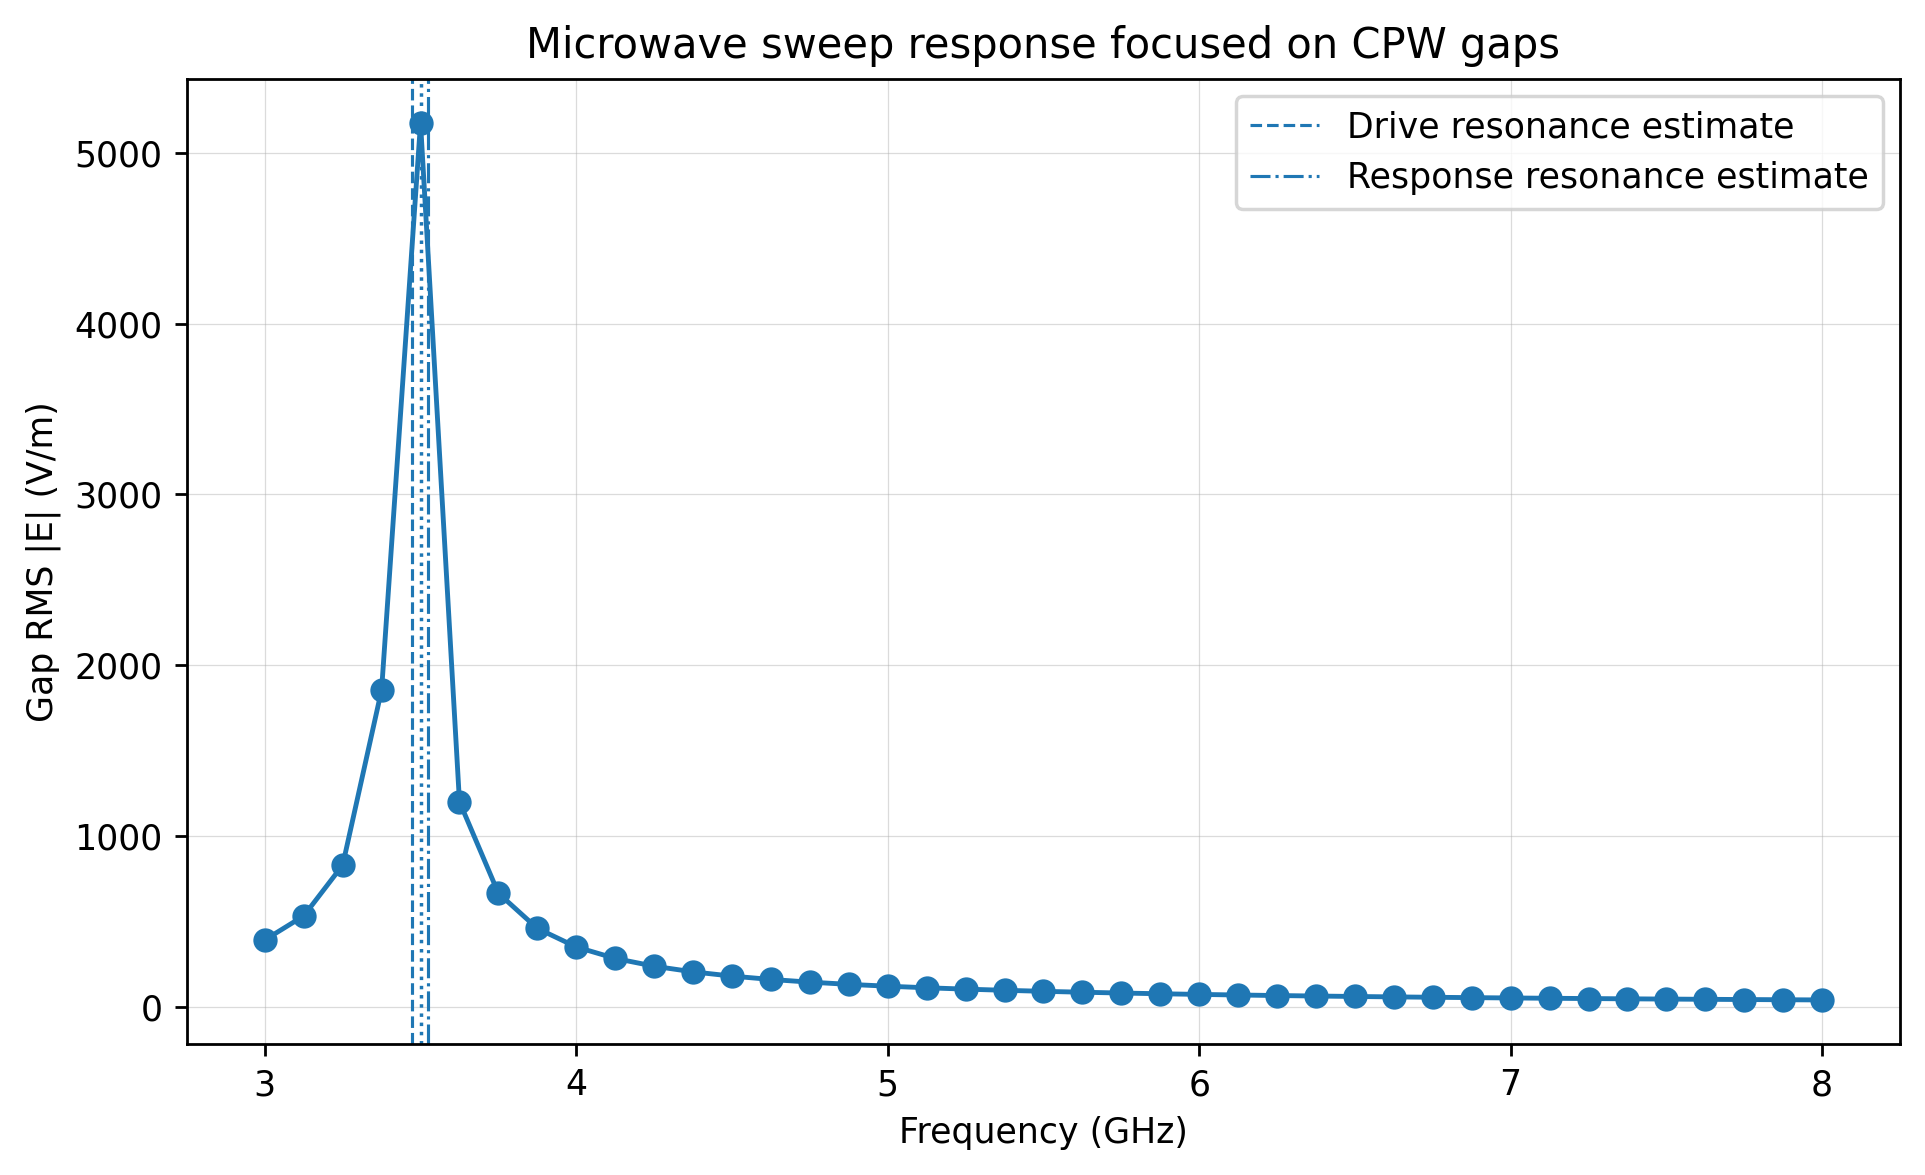

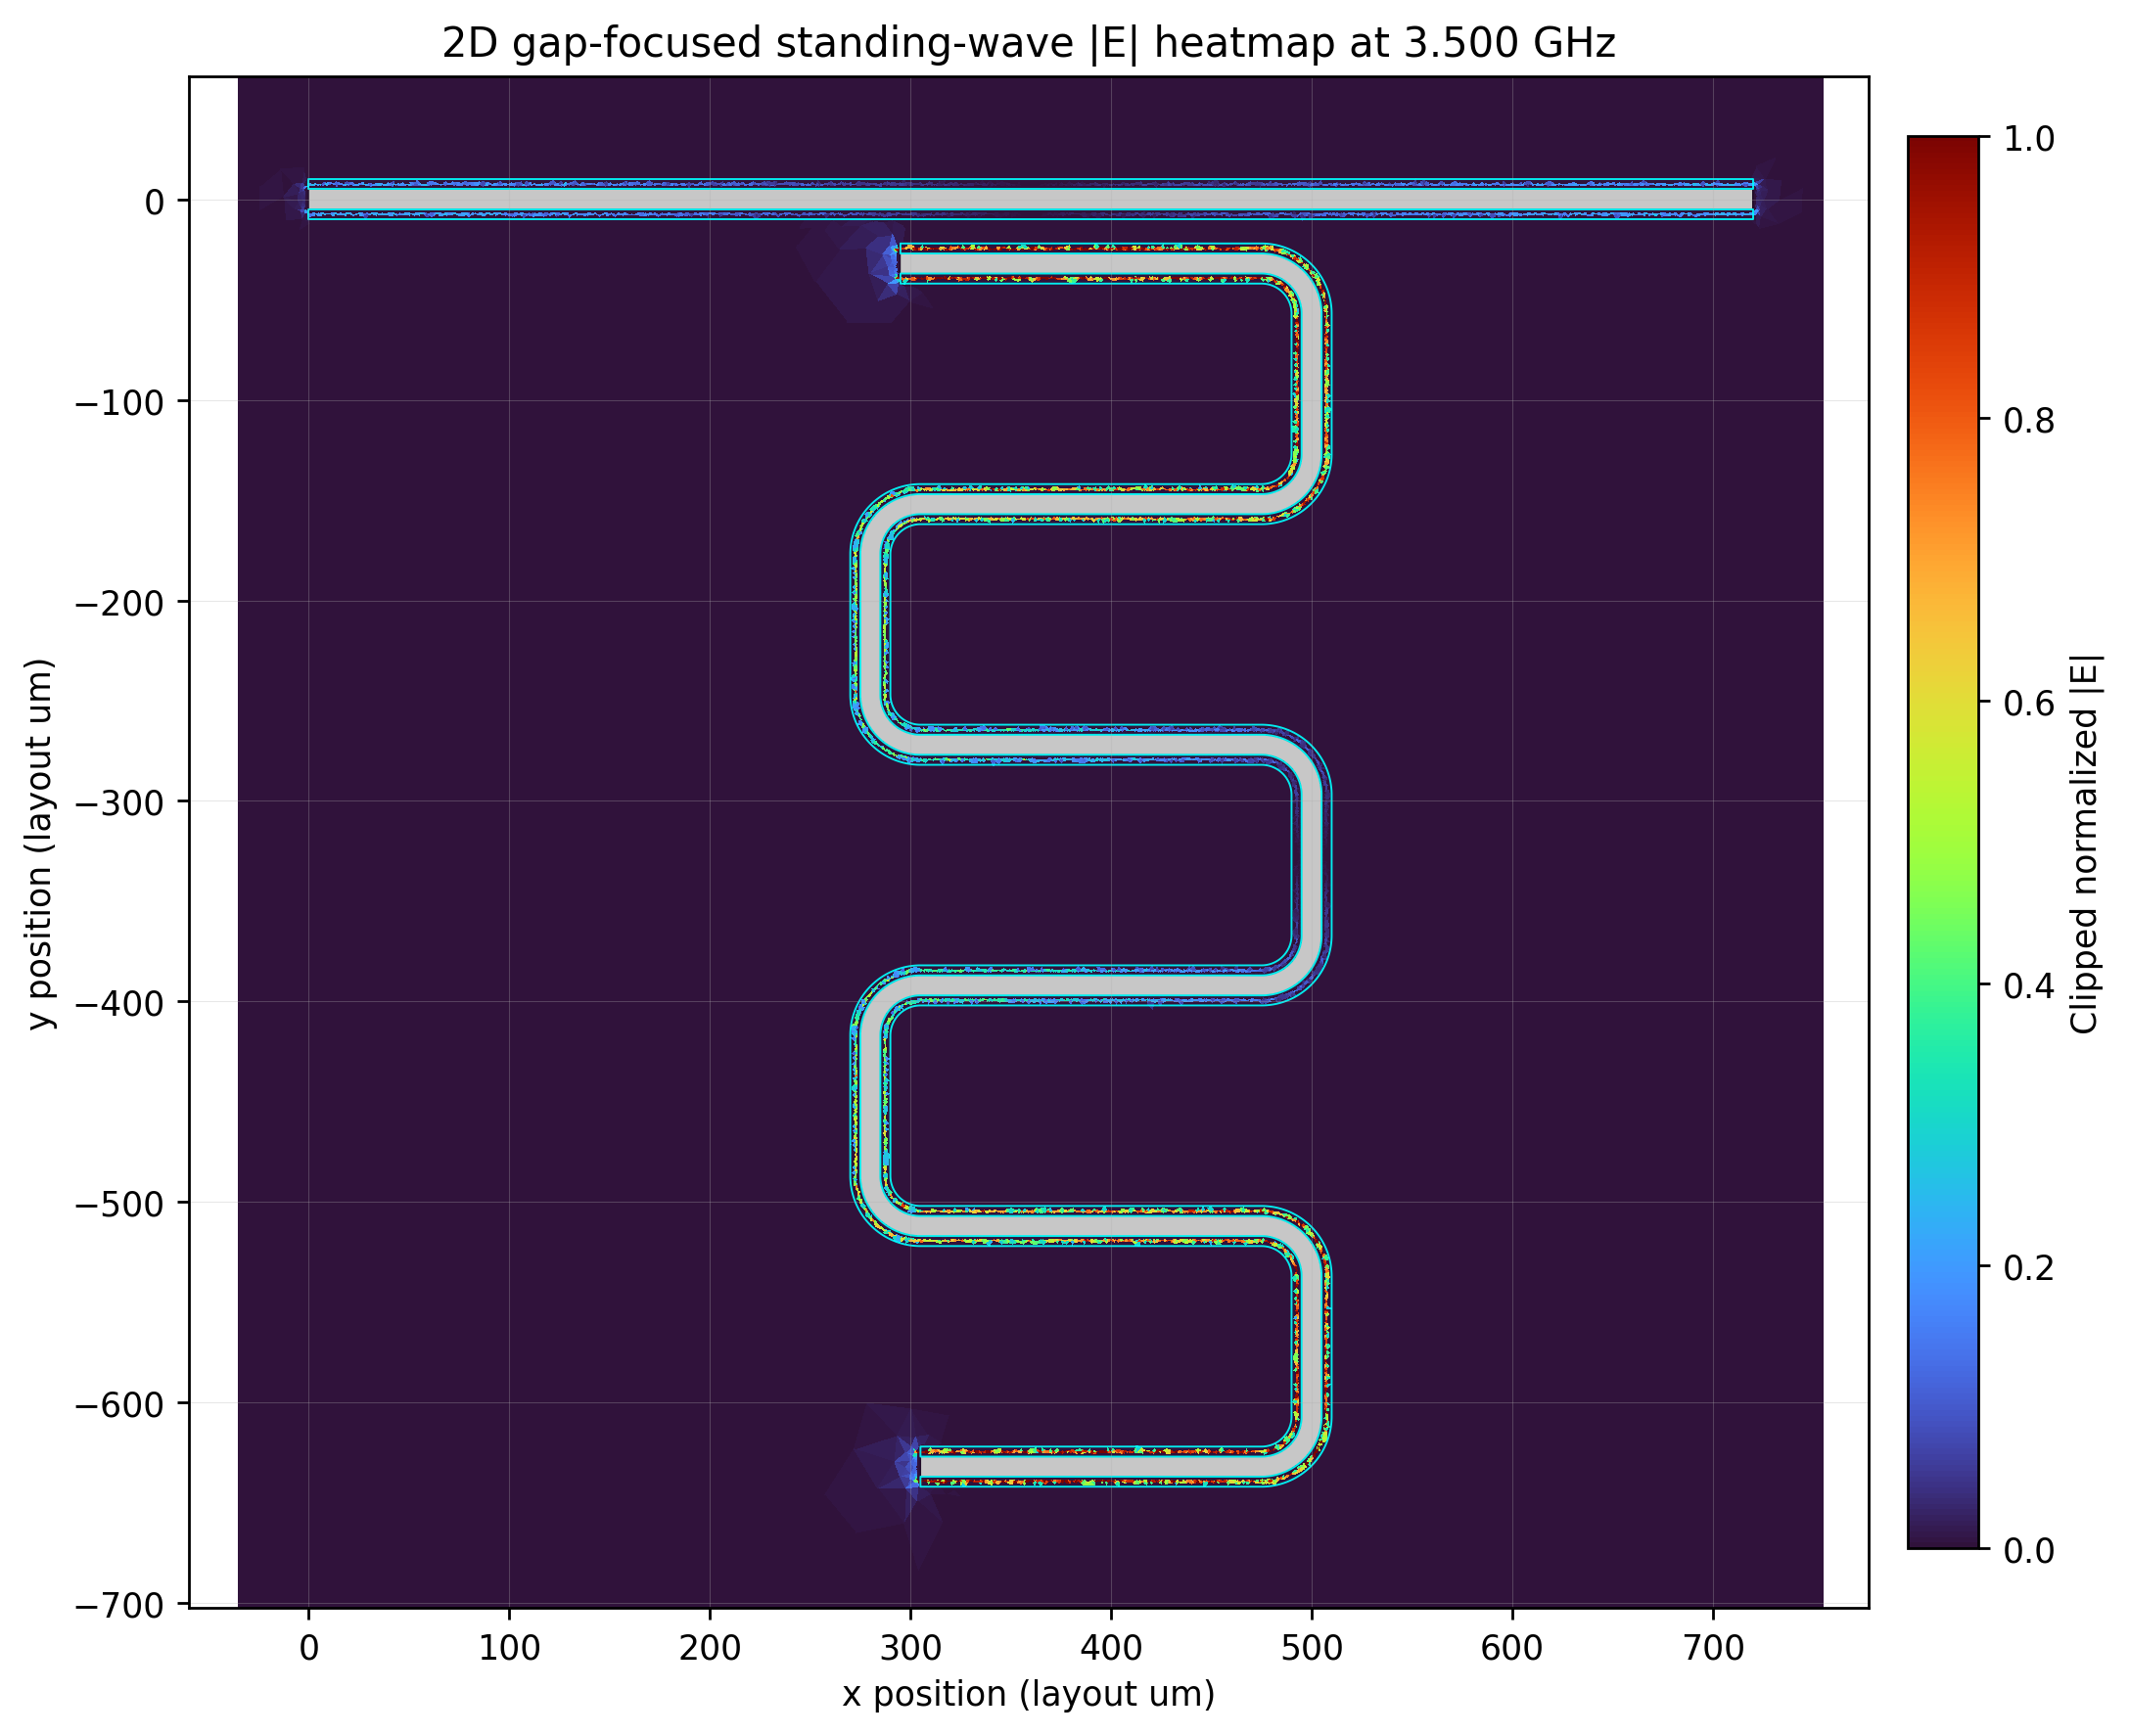

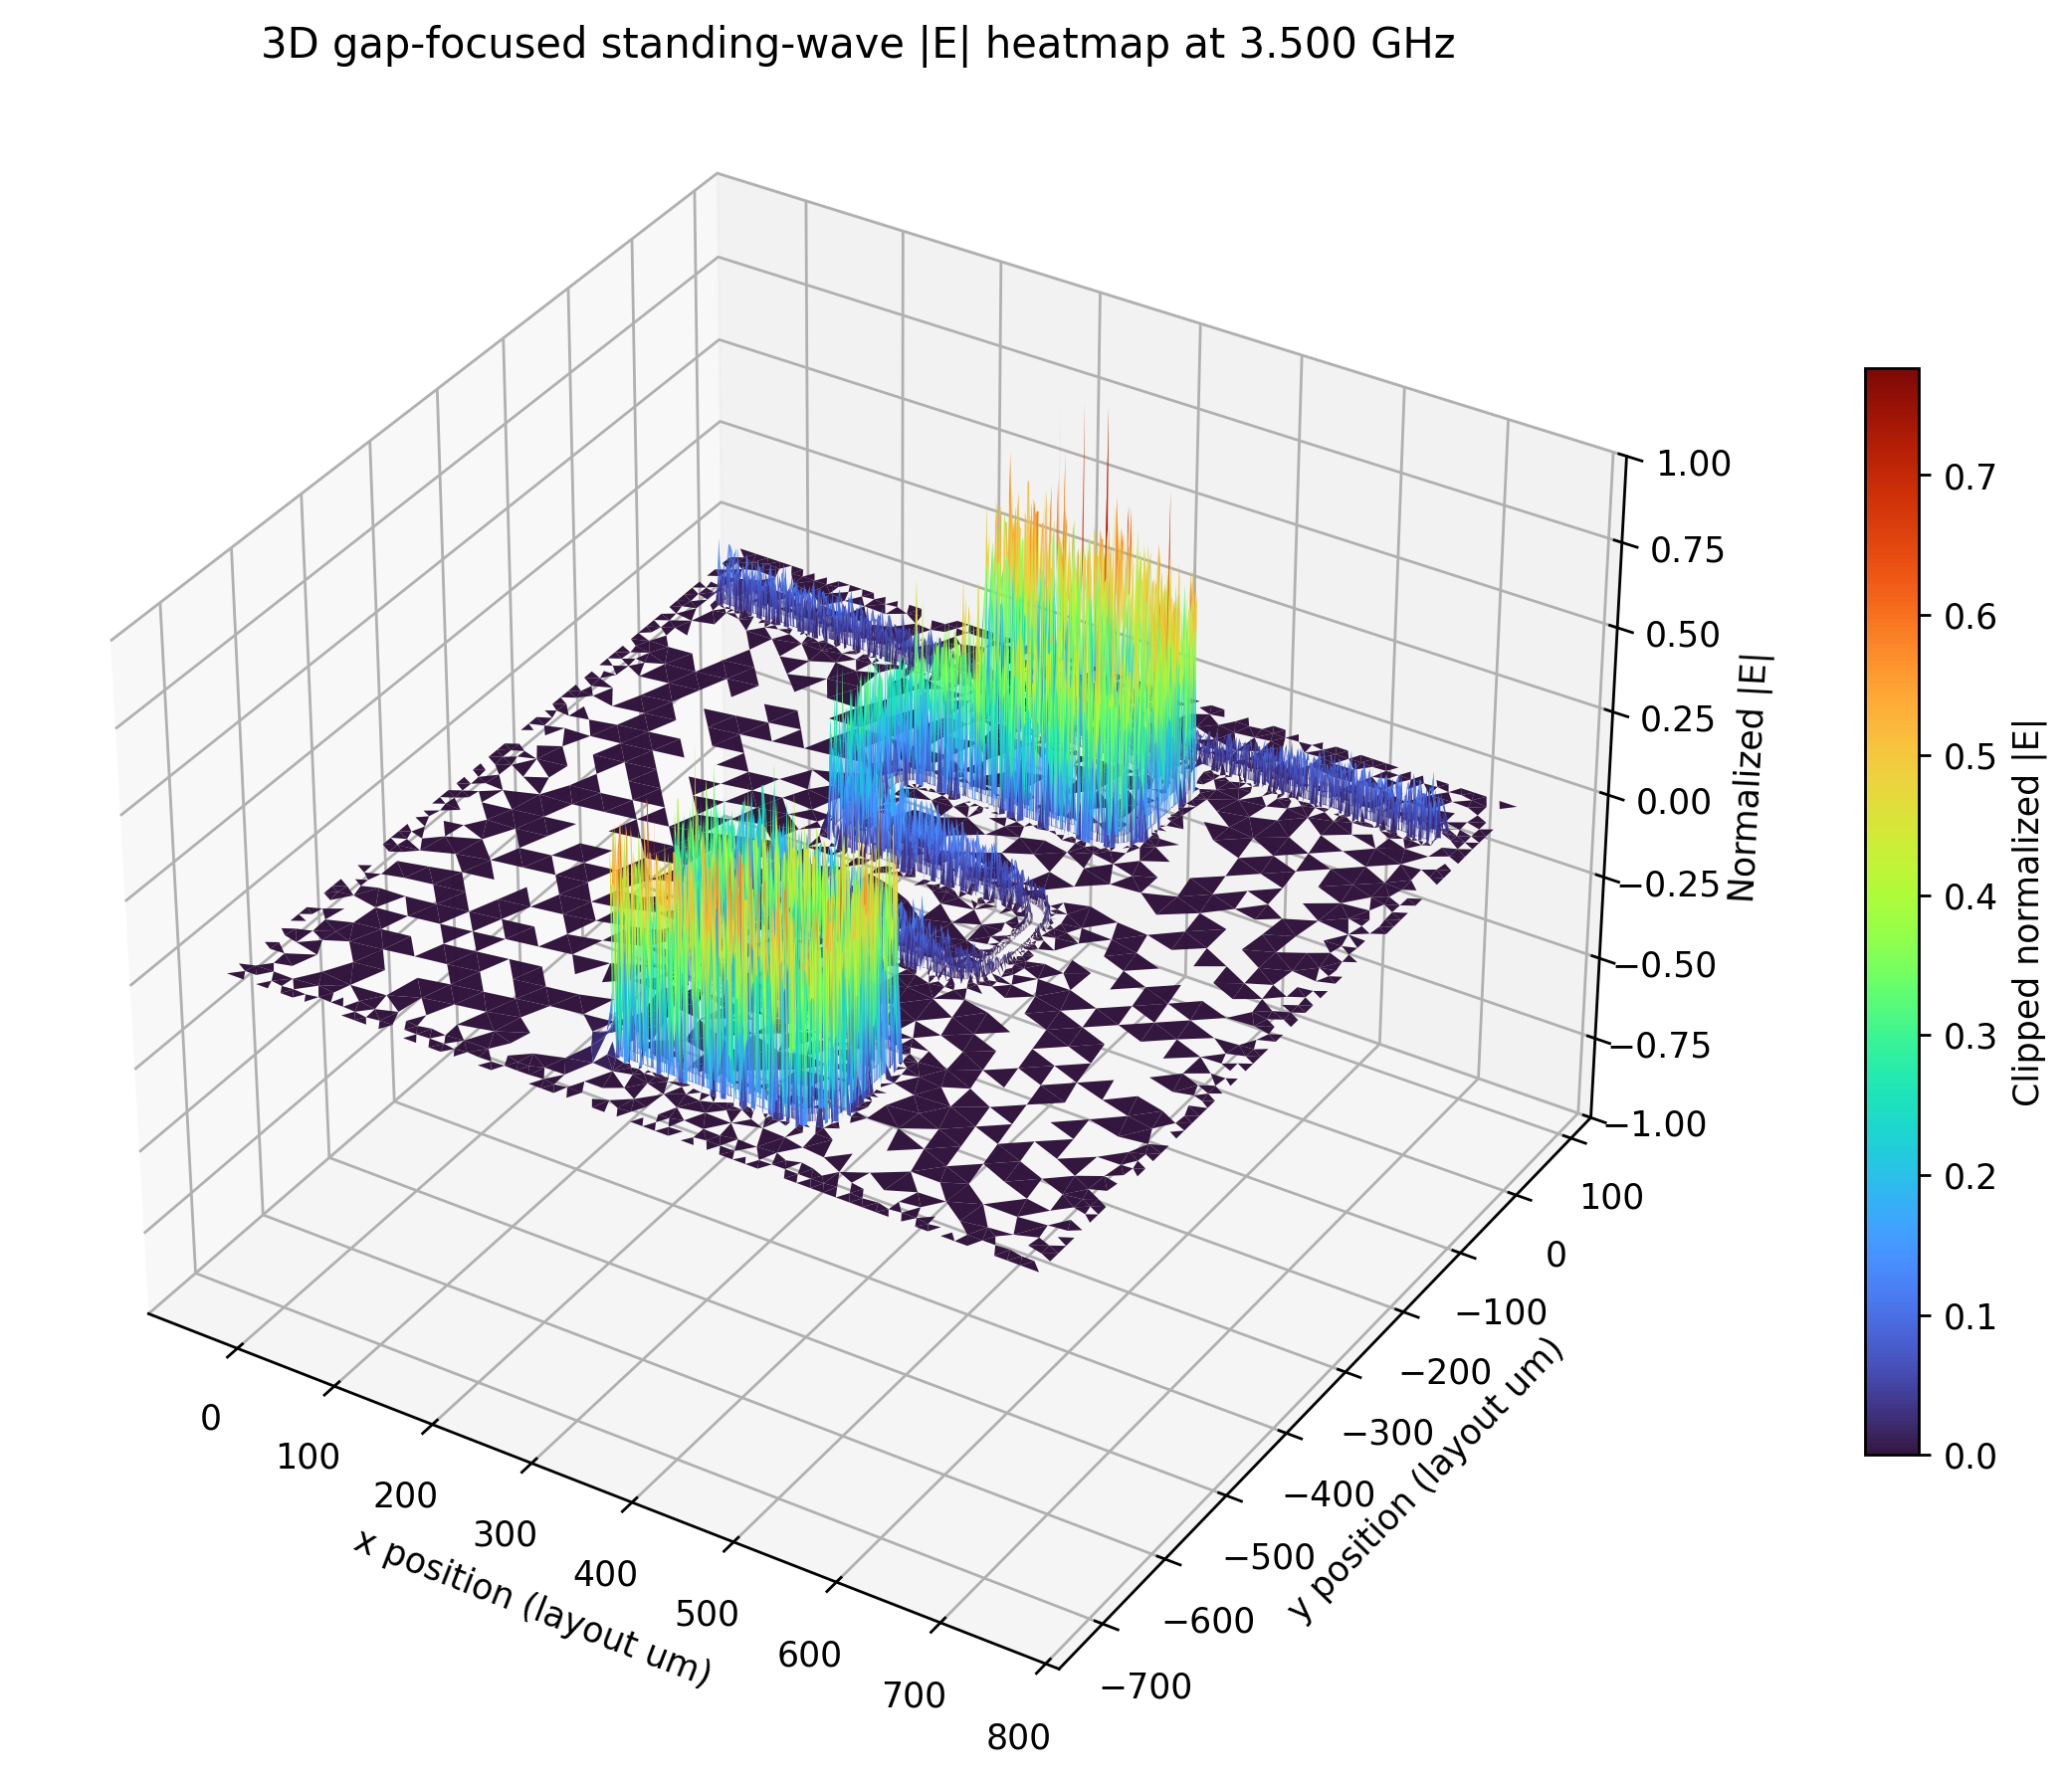

In [6]:
# Colab dependency installation.
!uv pip install --system -q scipy meshio matplotlib numpy cupy-cuda12x gdstk

"""
GPU-assisted quasi-TEM microwave sweep for a boxed meander-coupled CPW layout.

This cell loads the existing boxed Gmsh mesh from memory or from the mesh files
already present in the Colab working directory. It then applies standing-wave
Dirichlet voltages on the meander and straight CPW trace boundaries, grounds
the outer simulation box and ground-side slot edges, solves a 2D Laplace FEM
problem over a microwave frequency sweep, and renders the gap-focused response.

The model is a fast quasi-TEM visualization surrogate. It is suitable for
checking qualitative coupling, field localization, and standing-wave envelope
behavior. A calibrated microwave model requires a 3D material stack, vector
Maxwell fields, ports, conductor loss, dielectric loss, and radiation or PML
boundaries.
"""

from dataclasses import dataclass
from pathlib import Path
from typing import Any

import gdstk
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import meshio
import numpy as np
from matplotlib.collections import PatchCollection
from matplotlib.path import Path as MplPath
from matplotlib.patches import Polygon as MatplotlibPolygon
from scipy.sparse import coo_matrix, csr_matrix
from scipy.sparse.linalg import splu


# =============================================================================
# CONTROL KNOBS
# =============================================================================

MESH_GLOBAL_NAMES = (
    "boxed_cpw_gmsh_mesh",
    "gmsh_cpw_mesh",
)

POLYGON_GLOBAL_NAMES = (
    "boxed_cpw_source_polygons",
    "gmsh_cpw_source_polygons",
)

PHIDL_DEVICE_GLOBAL_NAMES = (
    "layout_device",
    "microwave_device",
)

MESH_INPUT_PATH_CANDIDATES = (
    Path("clean_boxed_meander_cpw_gmsh_mesh.msh"),
    Path("boxed_meander_cpw_gmsh_mesh.msh"),
    Path("faithful_cpw_boxed_gmsh_adaptive_with_trace.msh"),
)

LAYOUT_INPUT_PATH_CANDIDATES = (
    Path("continuous_right_facing_meander_cpw_coupler.oas"),
    Path("continuous_right_facing_meander_cpw_coupler_temp.gds"),
)

LAYER_TRACE = 1
LAYER_GAP = 2

LAYOUT_MICROMETER_TO_PHYSICAL_METER = 25.0e-6
CPW_PHASE_VELOCITY_M_PER_S = 1.25e8

FREQUENCY_START_GHZ = 3.0
FREQUENCY_STOP_GHZ = 8.0
FREQUENCY_COUNT = 41

AUTO_SET_RESONANCES_FROM_STRAIGHT = True
DRIVE_RESONANCE_GHZ = 5.00
RESPONSE_RESONANCE_GHZ = 5.06

DRIVE_QUALITY_FACTOR = 75.0
RESPONSE_QUALITY_FACTOR = 110.0
CAPACITIVE_COUPLING_FACTOR = 0.36

DRIVE_VOLTAGE_AMPLITUDE_V = 1.0
DRIVE_MODE_INDEX = 1
RESPONSE_MODE_INDEX = 1

TRACE_NODE_TOLERANCE_UM = 2.25
EDGE_NODE_TOLERANCE_UM = 2.25
OUTER_BOUNDARY_TOLERANCE_FRACTION = 1.0e-7
MIN_DIRICHLET_NODE_COUNT = 8

USE_CUPY_LINEAR_SOLVER = True
GPU_SOLVER_FALLBACK_TO_CPU_LU = True
CG_RELATIVE_TOLERANCE = 2.0e-5
CG_ABSOLUTE_TOLERANCE = 0.0
CG_MAX_ITERATIONS = 2500

GAP_FIELD_REGION_RADIUS_UM = 4.0
FIELD_PERCENTILE_CLIP = 99.3
TRACE_FIELD_MASKING = True

PLOT_DPI = 250
SWEEP_FIGURE_SIZE = (7.8, 4.8)
HEATMAP_2D_FIGURE_SIZE = (9.0, 7.2)
HEATMAP_3D_FIGURE_SIZE = (9.0, 7.4)
TRISURF_TRIANGLE_LIMIT = 30_000
GEOMETRY_OVERLAY_ALPHA = 0.92

AUTO_ZOOM_2D_MARGIN_FRACTION = 0.07
AUTO_ZOOM_2D_MIN_MARGIN_UM = 10.0
AUTO_ZOOM_2D_FIELD_THRESHOLD = 0.015
AUTO_ZOOM_2D_INCLUDE_ACTIVE_FIELD = True
AUTO_ZOOM_2D_LAYERS = (LAYER_TRACE, LAYER_GAP)

Z_AXIS_LOWER_LIMIT = -1.0
Z_AXIS_UPPER_LIMIT = 1.0

PRINT_SOLVE_PROGRESS = True


# =============================================================================
# DATA CONTAINERS
# =============================================================================

@dataclass(frozen=True)
class LayoutPolygon:
    """Store one layout polygon."""

    points_um: np.ndarray
    layer: int
    datatype: int = 0


@dataclass(frozen=True)
class MeshData:
    """Store mesh arrays in layout micrometer coordinates."""

    xy_um: np.ndarray
    triangles: np.ndarray


@dataclass(frozen=True)
class TraceRegions:
    """Store conductor boundary node sets and trace polygons."""

    drive_nodes: np.ndarray
    response_nodes: np.ndarray
    drive_polygon: LayoutPolygon
    response_polygon: LayoutPolygon
    drive_centerline_um: np.ndarray
    drive_centerline_s_um: np.ndarray


@dataclass(frozen=True)
class GroundRegions:
    """Store grounded node sets."""

    outer_nodes: np.ndarray
    gap_ground_nodes: np.ndarray
    all_ground_nodes: np.ndarray


@dataclass
class FemMatrices:
    """Store assembled FEM matrix data and solver state."""

    stiffness: csr_matrix
    free_nodes: np.ndarray
    dirichlet_nodes: np.ndarray
    using_gpu_solver: bool
    free_stiffness_cpu: Any = None
    free_stiffness_gpu: Any = None
    cpu_factorization: Any = None
    gpu_sparse_linalg: Any = None
    cupy_module: Any = None


@dataclass(frozen=True)
class SweepResult:
    """Store sweep results."""

    frequencies_hz: np.ndarray
    voltages: list[np.ndarray]
    element_field_norm_v_per_m: list[np.ndarray]
    gap_response: np.ndarray
    selected_index: int
    drive_resonance_ghz: float
    response_resonance_ghz: float


# =============================================================================
# BACKEND AND INPUT HELPERS
# =============================================================================

def configure_matplotlib() -> None:
    """Configure Matplotlib for high-resolution Colab rendering."""
    mpl.rcParams["figure.dpi"] = PLOT_DPI

    try:
        get_ipython().run_line_magic("matplotlib", "inline")
    except NameError:
        pass


def select_array_backend() -> tuple[Any, bool]:
    """Select CuPy when a CUDA GPU is available."""
    try:
        import cupy as cp

        if cp.cuda.runtime.getDeviceCount() > 0:
            return cp, True
    except Exception:
        pass

    return np, False


XP, USING_CUPY = select_array_backend()


def polygon_signed_area(points_um: np.ndarray) -> float:
    """Return signed polygon area in square micrometers."""
    points = np.asarray(points_um, dtype=float)
    x_values = points[:, 0]
    y_values = points[:, 1]

    return 0.5 * float(
        np.dot(x_values, np.roll(y_values, -1))
        - np.dot(y_values, np.roll(x_values, -1))
    )


def clean_polygon(points_um: np.ndarray) -> np.ndarray:
    """Clean polygon vertices and enforce counterclockwise order."""
    points = np.asarray(points_um, dtype=float)

    if len(points) >= 2 and np.linalg.norm(points[0] - points[-1]) < 1.0e-12:
        points = points[:-1]

    if len(points) < 3:
        return np.empty((0, 2), dtype=float)

    area_um2 = polygon_signed_area(points)

    if abs(area_um2) < 1.0e-12:
        return np.empty((0, 2), dtype=float)

    if area_um2 < 0.0:
        points = points[::-1]

    return points


def get_mesh_data() -> MeshData:
    """Return the Gmsh mesh from memory or from an existing mesh file."""
    for global_name in MESH_GLOBAL_NAMES:
        candidate = globals().get(global_name)

        if candidate is None:
            continue

        if hasattr(candidate, "xy_coordinates_um"):
            print(f"Using mesh from global variable: {global_name}")
            return MeshData(
                xy_um=np.asarray(candidate.xy_coordinates_um, dtype=float),
                triangles=np.asarray(candidate.triangles, dtype=int),
            )

        if hasattr(candidate, "xy_um"):
            print(f"Using mesh from global variable: {global_name}")
            return MeshData(
                xy_um=np.asarray(candidate.xy_um, dtype=float),
                triangles=np.asarray(candidate.triangles, dtype=int),
            )

    for mesh_path in MESH_INPUT_PATH_CANDIDATES:
        if mesh_path.exists():
            print(f"Using mesh file: {mesh_path}")
            meshio_mesh = meshio.read(str(mesh_path))
            xy_um = np.asarray(meshio_mesh.points[:, :2], dtype=float)

            triangle_blocks = [
                cell_block.data
                for cell_block in meshio_mesh.cells
                if cell_block.type == "triangle"
            ]

            if len(triangle_blocks) == 0:
                raise RuntimeError("The selected mesh contains zero triangles.")

            triangles = np.vstack(triangle_blocks).astype(int, copy=False)
            return MeshData(xy_um=xy_um, triangles=triangles)

    available_files = sorted(Path(".").glob("*.msh"))
    available_names = ", ".join(path.name for path in available_files)
    searched_names = ", ".join(str(path) for path in MESH_INPUT_PATH_CANDIDATES)

    raise FileNotFoundError(
        "No usable mesh was found. Searched these paths: "
        f"{searched_names}. Available .msh files: {available_names}."
    )


def polygons_from_phidl_device() -> list[LayoutPolygon]:
    """Extract layout polygons from an existing PHIDL device in memory."""
    device = None

    for global_name in PHIDL_DEVICE_GLOBAL_NAMES:
        candidate = globals().get(global_name)
        if candidate is not None and hasattr(candidate, "get_polygons"):
            device = candidate
            print(f"Using PHIDL polygons from global variable: {global_name}")
            break

    if device is None:
        return []

    polygons = []
    polygons_by_spec = device.get_polygons(by_spec=True)

    for spec, point_sets in polygons_by_spec.items():
        if isinstance(spec, tuple):
            layer = int(spec[0])
            datatype = int(spec[1]) if len(spec) > 1 else 0
        else:
            layer = int(spec)
            datatype = 0

        for point_set in point_sets:
            points = clean_polygon(np.asarray(point_set, dtype=float))

            if len(points) >= 3:
                polygons.append(
                    LayoutPolygon(
                        points_um=points,
                        layer=layer,
                        datatype=datatype,
                    )
                )

    return polygons


def polygons_from_layout_file() -> list[LayoutPolygon]:
    """Extract layout polygons from an existing OASIS or GDS file."""
    for layout_path in LAYOUT_INPUT_PATH_CANDIDATES:
        if not layout_path.exists():
            continue

        print(f"Using layout file for polygons: {layout_path}")

        if layout_path.suffix.lower() == ".oas":
            library = gdstk.read_oas(str(layout_path))
        else:
            library = gdstk.read_gds(str(layout_path))

        polygons = []

        for cell in library.top_level():
            cell = cell.copy(name=f"{cell.name}_flattened")
            cell.flatten()

            for polygon in cell.polygons:
                points = clean_polygon(np.asarray(polygon.points, dtype=float))

                if len(points) >= 3:
                    polygons.append(
                        LayoutPolygon(
                            points_um=points,
                            layer=int(polygon.layer),
                            datatype=int(polygon.datatype),
                        )
                    )

        if len(polygons) > 0:
            return polygons

    return []


def get_layout_polygons() -> list[LayoutPolygon]:
    """Return layout polygons from memory, PHIDL, or layout file."""
    for global_name in POLYGON_GLOBAL_NAMES:
        candidate = globals().get(global_name)

        if candidate is None:
            continue

        print(f"Using layout polygons from global variable: {global_name}")
        polygons = []

        for polygon in candidate:
            polygons.append(
                LayoutPolygon(
                    points_um=np.asarray(polygon.points_um, dtype=float),
                    layer=int(polygon.layer),
                    datatype=int(getattr(polygon, "datatype", 0)),
                )
            )

        if len(polygons) > 0:
            return polygons

    polygons = polygons_from_phidl_device()

    if len(polygons) > 0:
        return polygons

    polygons = polygons_from_layout_file()

    if len(polygons) > 0:
        return polygons

    searched_names = ", ".join(str(path) for path in LAYOUT_INPUT_PATH_CANDIDATES)
    raise FileNotFoundError(
        "No layout polygons were found in memory or layout files. "
        f"Searched layout files: {searched_names}."
    )


# =============================================================================
# GEOMETRY REGION DETECTION
# =============================================================================

def polygon_bounds(points_um: np.ndarray) -> tuple[float, float, float, float]:
    """Return xmin, ymin, xmax, ymax bounds."""
    points = np.asarray(points_um, dtype=float)

    return (
        float(np.min(points[:, 0])),
        float(np.min(points[:, 1])),
        float(np.max(points[:, 0])),
        float(np.max(points[:, 1])),
    )


def polygon_x_span(points_um: np.ndarray) -> float:
    """Return polygon x-span."""
    return float(np.ptp(np.asarray(points_um)[:, 0]))


def polygon_y_span(points_um: np.ndarray) -> float:
    """Return polygon y-span."""
    return float(np.ptp(np.asarray(points_um)[:, 1]))


def polygon_segments(points_um: np.ndarray) -> np.ndarray:
    """Return closed polygon segments with shape (N, 2, 2)."""
    points = np.asarray(points_um, dtype=float)
    return np.stack([points, np.roll(points, -1, axis=0)], axis=1)


def point_to_segments_min_distance(
    points_um: np.ndarray,
    segments_um: np.ndarray,
) -> np.ndarray:
    """Return minimum point-to-segment distance for each point."""
    points = points_um[:, None, :]
    starts = segments_um[None, :, 0, :]
    ends = segments_um[None, :, 1, :]

    segment_vectors = ends - starts
    point_vectors = points - starts

    lengths_sq = np.sum(segment_vectors**2, axis=2)
    lengths_sq = np.maximum(lengths_sq, 1.0e-30)

    projection = np.sum(point_vectors * segment_vectors, axis=2) / lengths_sq
    projection = np.clip(projection, 0.0, 1.0)

    closest = starts + projection[:, :, None] * segment_vectors
    distances = np.linalg.norm(points - closest, axis=2)

    return np.min(distances, axis=1)


def points_inside_polygon_mask(
    points_um: np.ndarray,
    polygon_um: np.ndarray,
    radius_um: float = 0.0,
) -> np.ndarray:
    """Return a mask for points inside a polygon."""
    path = MplPath(np.asarray(polygon_um, dtype=float), closed=True)

    return path.contains_points(points_um, radius=radius_um)


def get_trace_polygons(polygons: list[LayoutPolygon]) -> list[LayoutPolygon]:
    """Return trace-layer polygons."""
    trace_polygons = [
        polygon
        for polygon in polygons
        if polygon.layer == LAYER_TRACE
    ]

    if len(trace_polygons) < 2:
        raise RuntimeError("At least two trace-layer polygons are required.")

    return trace_polygons


def identify_straight_and_meander_polygons(
    polygons: list[LayoutPolygon],
) -> tuple[LayoutPolygon, LayoutPolygon]:
    """Identify straight and meander trace polygons."""
    trace_polygons = get_trace_polygons(polygons)

    def straightness_score(polygon: LayoutPolygon) -> float:
        x_span = polygon_x_span(polygon.points_um)
        y_span = max(polygon_y_span(polygon.points_um), 1.0e-9)
        return x_span / y_span

    straight_polygon = max(trace_polygons, key=straightness_score)
    remaining = [
        polygon
        for polygon in trace_polygons
        if polygon is not straight_polygon
    ]

    meander_polygon = max(
        remaining,
        key=lambda polygon: abs(polygon_signed_area(polygon.points_um)),
    )

    return straight_polygon, meander_polygon


def find_nodes_near_polygon_boundary(
    mesh_data: MeshData,
    polygon: LayoutPolygon,
    tolerance_um: float,
) -> np.ndarray:
    """Find mesh nodes close to a polygon boundary."""
    segments = polygon_segments(polygon.points_um)
    distances = point_to_segments_min_distance(mesh_data.xy_um, segments)
    nodes = np.flatnonzero(distances <= tolerance_um)

    if len(nodes) >= MIN_DIRICHLET_NODE_COUNT:
        return nodes.astype(int, copy=False)

    nearest_count = min(MIN_DIRICHLET_NODE_COUNT, len(mesh_data.xy_um))
    return np.argsort(distances)[:nearest_count].astype(int, copy=False)


def find_outer_boundary_nodes(mesh_data: MeshData) -> np.ndarray:
    """Find nodes on the rectangular outer boundary."""
    x_values = mesh_data.xy_um[:, 0]
    y_values = mesh_data.xy_um[:, 1]

    xmin = float(np.min(x_values))
    xmax = float(np.max(x_values))
    ymin = float(np.min(y_values))
    ymax = float(np.max(y_values))

    span = max(xmax - xmin, ymax - ymin, 1.0)
    tolerance = OUTER_BOUNDARY_TOLERANCE_FRACTION * span

    mask = (
        np.isclose(x_values, xmin, atol=tolerance)
        | np.isclose(x_values, xmax, atol=tolerance)
        | np.isclose(y_values, ymin, atol=tolerance)
        | np.isclose(y_values, ymax, atol=tolerance)
    )

    return np.flatnonzero(mask).astype(int, copy=False)


def collect_gap_ground_segments(polygons: list[LayoutPolygon]) -> np.ndarray:
    """Collect ground-side CPW gap edges."""
    trace_segments = []
    gap_segments = []

    for polygon in polygons:
        if polygon.layer == LAYER_TRACE:
            trace_segments.append(polygon_segments(polygon.points_um))
        elif polygon.layer == LAYER_GAP:
            gap_segments.append(polygon_segments(polygon.points_um))

    if len(gap_segments) == 0:
        return np.empty((0, 2, 2), dtype=float)

    all_gap_segments = np.concatenate(gap_segments, axis=0)

    if len(trace_segments) == 0:
        return all_gap_segments

    all_trace_segments = np.concatenate(trace_segments, axis=0)
    midpoints = 0.5 * (all_gap_segments[:, 0, :] + all_gap_segments[:, 1, :])
    distances = point_to_segments_min_distance(midpoints, all_trace_segments)

    return all_gap_segments[distances > EDGE_NODE_TOLERANCE_UM]


def find_gap_ground_nodes(
    mesh_data: MeshData,
    polygons: list[LayoutPolygon],
) -> np.ndarray:
    """Find nodes close to ground-side gap edges."""
    segments = collect_gap_ground_segments(polygons)

    if len(segments) == 0:
        return np.empty(0, dtype=int)

    distances = point_to_segments_min_distance(mesh_data.xy_um, segments)

    return np.flatnonzero(distances <= EDGE_NODE_TOLERANCE_UM).astype(
        int,
        copy=False,
    )


# =============================================================================
# CENTERLINE AND STANDING-WAVE MODEL
# =============================================================================

def get_global_float(name: str, default: float) -> float:
    """Return a global float control value."""
    return float(globals().get(name, default))


def get_global_int(name: str, default: int) -> int:
    """Return a global integer control value."""
    return int(globals().get(name, default))


def get_global_str(name: str, default: str) -> str:
    """Return a global string control value."""
    return str(globals().get(name, default))


def rotate_vectors(vectors: np.ndarray, angle_rad: float) -> np.ndarray:
    """Rotate vectors in the xy plane."""
    cos_value = np.cos(angle_rad)
    sin_value = np.sin(angle_rad)

    rotation = np.array(
        [
            [cos_value, -sin_value],
            [sin_value, cos_value],
        ],
        dtype=float,
    )

    return vectors @ rotation.T


def append_straight_segment(
    points: list[np.ndarray],
    s_values: list[float],
    position: np.ndarray,
    heading_rad: float,
    length_um: float,
    sample_count: int,
) -> tuple[np.ndarray, float]:
    """Append a sampled straight segment."""
    direction = np.array([np.cos(heading_rad), np.sin(heading_rad)])
    start_s = s_values[-1]

    for index in range(1, sample_count + 1):
        fraction = index / sample_count
        points.append(position + fraction * length_um * direction)
        s_values.append(start_s + fraction * length_um)

    return position + length_um * direction, start_s + length_um


def append_arc_segment(
    points: list[np.ndarray],
    s_values: list[float],
    position: np.ndarray,
    heading_rad: float,
    radius_um: float,
    angle_deg: float,
    sample_count: int,
) -> tuple[np.ndarray, float, float]:
    """Append a sampled circular arc."""
    angle_rad = np.deg2rad(angle_deg)
    turn_sign = 1.0 if angle_rad >= 0.0 else -1.0

    tangent = np.array([np.cos(heading_rad), np.sin(heading_rad)])
    left_normal = np.array([-tangent[1], tangent[0]])
    center = position + turn_sign * radius_um * left_normal
    radius_vector = position - center
    start_s = s_values[-1]
    arc_length = abs(angle_rad) * radius_um

    for index in range(1, sample_count + 1):
        fraction = index / sample_count
        local_angle = fraction * angle_rad
        point = center + rotate_vectors(
            radius_vector[None, :],
            local_angle,
        )[0]
        points.append(point)
        s_values.append(start_s + fraction * arc_length)

    final_position = points[-1]
    final_heading = heading_rad + angle_rad
    final_s = start_s + arc_length

    return final_position, final_heading, final_s


def get_side_sign(side: str) -> float:
    """Return signed meander side."""
    if side == "above":
        return 1.0

    return -1.0


def get_turn_angle_degrees(horizontal_index: int, side: str) -> float:
    """Return signed serpentine turn angle."""
    side_sign = get_side_sign(side)

    if horizontal_index % 2 == 0:
        return 90.0 * side_sign

    return -90.0 * side_sign


def sample_local_meander_centerline() -> tuple[np.ndarray, np.ndarray]:
    """Sample the expected continuous right-facing meander centerline."""
    coupling_length_um = get_global_float(
        "MEANDER_COUPLING_ARM_LENGTH_UM",
        180.0,
    )
    bend_radius_um = get_global_float(
        "MEANDER_ELBOW_BEND_RADIUS_UM",
        25.0,
    )
    vertical_drop_um = get_global_float(
        "MEANDER_VERTICAL_DROP_AFTER_COUPLER_UM",
        70.0,
    )
    run_length_um = get_global_float("MEANDER_RUN_LENGTH_UM", 170.0)
    run_count = get_global_int("MEANDER_RUN_COUNT", 5)
    connector_length_um = get_global_float(
        "MEANDER_VERTICAL_CONNECTOR_LENGTH_UM",
        70.0,
    )
    side = get_global_str("MEANDER_SIDE", "below")

    points = [np.array([0.0, 0.0], dtype=float)]
    s_values = [0.0]
    position = np.array([0.0, 0.0], dtype=float)
    heading_rad = 0.0

    horizontal_segment_count = run_count + 1

    for horizontal_index in range(horizontal_segment_count):
        length_um = (
            coupling_length_um
            if horizontal_index == 0
            else run_length_um
        )
        position, _ = append_straight_segment(
            points=points,
            s_values=s_values,
            position=position,
            heading_rad=heading_rad,
            length_um=length_um,
            sample_count=max(40, int(length_um / 2.0)),
        )

        if horizontal_index < horizontal_segment_count - 1:
            turn_angle = get_turn_angle_degrees(
                horizontal_index=horizontal_index,
                side=side,
            )
            vertical_length_um = (
                vertical_drop_um
                if horizontal_index == 0
                else connector_length_um
            )

            position, heading_rad, _ = append_arc_segment(
                points=points,
                s_values=s_values,
                position=position,
                heading_rad=heading_rad,
                radius_um=bend_radius_um,
                angle_deg=turn_angle,
                sample_count=32,
            )
            position, _ = append_straight_segment(
                points=points,
                s_values=s_values,
                position=position,
                heading_rad=heading_rad,
                length_um=vertical_length_um,
                sample_count=max(24, int(vertical_length_um / 2.0)),
            )
            position, heading_rad, _ = append_arc_segment(
                points=points,
                s_values=s_values,
                position=position,
                heading_rad=heading_rad,
                radius_um=bend_radius_um,
                angle_deg=turn_angle,
                sample_count=32,
            )

    return np.vstack(points), np.asarray(s_values, dtype=float)


def align_centerline_to_polygon(
    centerline_um: np.ndarray,
    polygon: LayoutPolygon,
) -> np.ndarray:
    """Align sampled centerline to a polygon by bounding-box centers."""
    cl_xmin, cl_ymin, cl_xmax, cl_ymax = polygon_bounds(centerline_um)
    pg_xmin, pg_ymin, pg_xmax, pg_ymax = polygon_bounds(polygon.points_um)

    cl_center = np.array(
        [0.5 * (cl_xmin + cl_xmax), 0.5 * (cl_ymin + cl_ymax)],
        dtype=float,
    )
    pg_center = np.array(
        [0.5 * (pg_xmin + pg_xmax), 0.5 * (pg_ymin + pg_ymax)],
        dtype=float,
    )

    return centerline_um + (pg_center - cl_center)


def nearest_path_coordinate(
    points_um: np.ndarray,
    centerline_um: np.ndarray,
    centerline_s_um: np.ndarray,
) -> tuple[np.ndarray, float]:
    """Map points to nearest sampled centerline coordinate."""
    deltas = points_um[:, None, :] - centerline_um[None, :, :]
    distances_sq = np.sum(deltas**2, axis=2)
    nearest_indices = np.argmin(distances_sq, axis=1)

    return centerline_s_um[nearest_indices], float(centerline_s_um[-1])


def straight_path_coordinate(
    points_um: np.ndarray,
    polygon: LayoutPolygon,
) -> tuple[np.ndarray, float]:
    """Map points on a straight trace to x-directed coordinate."""
    x_min = float(np.min(polygon.points_um[:, 0]))
    x_max = float(np.max(polygon.points_um[:, 0]))
    length_um = max(x_max - x_min, 1.0e-12)
    s_um = np.clip(points_um[:, 0] - x_min, 0.0, length_um)

    return s_um, length_um


def identify_trace_regions(
    mesh_data: MeshData,
    polygons: list[LayoutPolygon],
) -> TraceRegions:
    """Identify meander drive and straight response trace regions."""
    straight_polygon, meander_polygon = identify_straight_and_meander_polygons(
        polygons,
    )

    drive_nodes = find_nodes_near_polygon_boundary(
        mesh_data=mesh_data,
        polygon=meander_polygon,
        tolerance_um=TRACE_NODE_TOLERANCE_UM,
    )
    response_nodes = find_nodes_near_polygon_boundary(
        mesh_data=mesh_data,
        polygon=straight_polygon,
        tolerance_um=TRACE_NODE_TOLERANCE_UM,
    )

    local_centerline_um, centerline_s_um = sample_local_meander_centerline()
    drive_centerline_um = align_centerline_to_polygon(
        centerline_um=local_centerline_um,
        polygon=meander_polygon,
    )

    return TraceRegions(
        drive_nodes=np.asarray(drive_nodes, dtype=int),
        response_nodes=np.asarray(response_nodes, dtype=int),
        drive_polygon=meander_polygon,
        response_polygon=straight_polygon,
        drive_centerline_um=drive_centerline_um,
        drive_centerline_s_um=centerline_s_um,
    )


def identify_ground_regions(
    mesh_data: MeshData,
    polygons: list[LayoutPolygon],
    trace_regions: TraceRegions,
) -> GroundRegions:
    """Identify grounded outer and slot-edge nodes."""
    outer_nodes = find_outer_boundary_nodes(mesh_data)
    gap_ground_nodes = find_gap_ground_nodes(mesh_data, polygons)

    trace_nodes = np.union1d(
        trace_regions.drive_nodes,
        trace_regions.response_nodes,
    )
    gap_ground_nodes = np.setdiff1d(gap_ground_nodes, trace_nodes)
    all_ground_nodes = np.union1d(outer_nodes, gap_ground_nodes)

    return GroundRegions(
        outer_nodes=outer_nodes,
        gap_ground_nodes=gap_ground_nodes,
        all_ground_nodes=all_ground_nodes,
    )


def standing_wave_profile(
    s_um: np.ndarray,
    length_um: float,
    mode_index: int,
) -> np.ndarray:
    """Return an open-ended standing-wave voltage profile."""
    coordinate = np.clip(s_um / max(length_um, 1.0e-12), 0.0, 1.0)

    return np.cos(mode_index * np.pi * coordinate)


def infer_model_resonances_ghz(
    trace_regions: TraceRegions,
) -> tuple[float, float]:
    """Infer approximate resonances from straight CPW trace length."""
    _, straight_length_um = straight_path_coordinate(
        trace_regions.response_polygon.points_um,
        trace_regions.response_polygon,
    )

    physical_length_m = straight_length_um * LAYOUT_MICROMETER_TO_PHYSICAL_METER
    fundamental_hz = CPW_PHASE_VELOCITY_M_PER_S / (2.0 * physical_length_m)
    drive_resonance_ghz = DRIVE_MODE_INDEX * fundamental_hz / 1.0e9
    response_resonance_ghz = 1.015 * drive_resonance_ghz

    if AUTO_SET_RESONANCES_FROM_STRAIGHT:
        return drive_resonance_ghz, response_resonance_ghz

    return DRIVE_RESONANCE_GHZ, RESPONSE_RESONANCE_GHZ


def coupled_mode_amplitudes(
    frequency_hz: float,
    drive_resonance_ghz: float,
    response_resonance_ghz: float,
) -> tuple[complex, complex]:
    """Return complex drive and coupled-resonator amplitudes."""
    frequency_ghz = frequency_hz / 1.0e9

    drive_detuning = (
        (frequency_ghz - drive_resonance_ghz)
        / max(drive_resonance_ghz, 1.0e-12)
    )
    response_detuning = (
        (frequency_ghz - response_resonance_ghz)
        / max(response_resonance_ghz, 1.0e-12)
    )

    drive_amplitude = 1.0 / (
        1.0 + 2.0j * DRIVE_QUALITY_FACTOR * drive_detuning
    )
    response_amplitude = (
        CAPACITIVE_COUPLING_FACTOR
        * drive_amplitude
        / (1.0 + 2.0j * RESPONSE_QUALITY_FACTOR * response_detuning)
    )

    return drive_amplitude, response_amplitude


def build_dirichlet_values(
    mesh_data: MeshData,
    trace_regions: TraceRegions,
    ground_regions: GroundRegions,
    frequency_hz: float,
    drive_resonance_ghz: float,
    response_resonance_ghz: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Build complex Dirichlet node indices and values."""
    voltage = np.zeros(len(mesh_data.xy_um), dtype=np.complex128)

    drive_amplitude, response_amplitude = coupled_mode_amplitudes(
        frequency_hz=frequency_hz,
        drive_resonance_ghz=drive_resonance_ghz,
        response_resonance_ghz=response_resonance_ghz,
    )

    drive_points = mesh_data.xy_um[trace_regions.drive_nodes]
    drive_s_um, drive_length_um = nearest_path_coordinate(
        points_um=drive_points,
        centerline_um=trace_regions.drive_centerline_um,
        centerline_s_um=trace_regions.drive_centerline_s_um,
    )
    drive_profile = standing_wave_profile(
        s_um=drive_s_um,
        length_um=drive_length_um,
        mode_index=DRIVE_MODE_INDEX,
    )

    response_points = mesh_data.xy_um[trace_regions.response_nodes]
    response_s_um, response_length_um = straight_path_coordinate(
        points_um=response_points,
        polygon=trace_regions.response_polygon,
    )
    response_profile = standing_wave_profile(
        s_um=response_s_um,
        length_um=response_length_um,
        mode_index=RESPONSE_MODE_INDEX,
    )

    voltage[ground_regions.all_ground_nodes] = 0.0 + 0.0j
    voltage[trace_regions.drive_nodes] = (
        DRIVE_VOLTAGE_AMPLITUDE_V * drive_amplitude * drive_profile
    )
    voltage[trace_regions.response_nodes] = (
        DRIVE_VOLTAGE_AMPLITUDE_V * response_amplitude * response_profile
    )

    dirichlet_nodes = np.union1d(
        ground_regions.all_ground_nodes,
        np.union1d(trace_regions.drive_nodes, trace_regions.response_nodes),
    )

    return dirichlet_nodes, voltage[dirichlet_nodes]


# =============================================================================
# FEM ASSEMBLY AND SOLVE
# =============================================================================

def assemble_laplace_stiffness(mesh_data: MeshData) -> csr_matrix:
    """Assemble scalar P1 triangular Laplace stiffness matrix."""
    points_m = mesh_data.xy_um * LAYOUT_MICROMETER_TO_PHYSICAL_METER
    triangles = mesh_data.triangles
    coords = points_m[triangles]

    x0 = coords[:, 0, 0]
    y0 = coords[:, 0, 1]
    x1 = coords[:, 1, 0]
    y1 = coords[:, 1, 1]
    x2 = coords[:, 2, 0]
    y2 = coords[:, 2, 1]

    twice_area = (x1 - x0) * (y2 - y0) - (x2 - x0) * (y1 - y0)
    valid = np.abs(twice_area) > 0.0

    triangles = triangles[valid]
    area = 0.5 * np.abs(twice_area[valid])

    b_values = np.column_stack(
        [
            y1[valid] - y2[valid],
            y2[valid] - y0[valid],
            y0[valid] - y1[valid],
        ]
    )
    c_values = np.column_stack(
        [
            x2[valid] - x1[valid],
            x0[valid] - x2[valid],
            x1[valid] - x0[valid],
        ]
    )

    local = (
        b_values[:, :, None] * b_values[:, None, :]
        + c_values[:, :, None] * c_values[:, None, :]
    ) / (4.0 * area[:, None, None])

    rows = np.repeat(triangles, 3, axis=1).ravel()
    cols = np.tile(triangles, (1, 3)).ravel()
    values = local.reshape(-1)

    node_count = len(mesh_data.xy_um)

    return coo_matrix(
        (values, (rows, cols)),
        shape=(node_count, node_count),
    ).tocsr()


def try_build_gpu_matrix(free_stiffness_cpu: csr_matrix) -> tuple[Any, Any, Any]:
    """Transfer free-node matrix to CuPy sparse format."""
    import cupy as cp
    import cupyx.scipy.sparse as cpx_sparse
    import cupyx.scipy.sparse.linalg as cpx_linalg

    free_stiffness_gpu = cpx_sparse.csr_matrix(free_stiffness_cpu)

    return cp, cpx_linalg, free_stiffness_gpu


def build_fem_matrices(
    stiffness: csr_matrix,
    dirichlet_nodes: np.ndarray,
) -> FemMatrices:
    """Build free-node matrices for fixed Dirichlet nodes."""
    node_count = stiffness.shape[0]
    all_nodes = np.arange(node_count, dtype=int)
    dirichlet_nodes = np.unique(dirichlet_nodes.astype(int, copy=False))
    free_nodes = np.setdiff1d(all_nodes, dirichlet_nodes)

    free_stiffness_cpu = stiffness[free_nodes][:, free_nodes].tocsr()

    using_gpu_solver = False
    free_stiffness_gpu = None
    cpx_linalg = None
    cp = None

    if USE_CUPY_LINEAR_SOLVER and USING_CUPY:
        try:
            cp, cpx_linalg, free_stiffness_gpu = try_build_gpu_matrix(
                free_stiffness_cpu,
            )
            using_gpu_solver = True
        except Exception as exc:
            print(f"GPU sparse setup failed; using CPU LU. Reason: {exc}")

    cpu_factorization = None
    if using_gpu_solver is False:
        cpu_factorization = splu(
            free_stiffness_cpu.astype(np.complex128).tocsc(),
        )

    return FemMatrices(
        stiffness=stiffness.astype(np.complex128).tocsr(),
        free_nodes=free_nodes,
        dirichlet_nodes=dirichlet_nodes,
        using_gpu_solver=using_gpu_solver,
        free_stiffness_cpu=free_stiffness_cpu,
        free_stiffness_gpu=free_stiffness_gpu,
        cpu_factorization=cpu_factorization,
        gpu_sparse_linalg=cpx_linalg,
        cupy_module=cp,
    )


def call_gpu_cg(fem: FemMatrices, rhs_gpu: Any) -> tuple[Any, int]:
    """Call CuPy CG across compatible signatures."""
    try:
        solution, info = fem.gpu_sparse_linalg.cg(
            fem.free_stiffness_gpu,
            rhs_gpu,
            rtol=CG_RELATIVE_TOLERANCE,
            atol=CG_ABSOLUTE_TOLERANCE,
            maxiter=CG_MAX_ITERATIONS,
        )
    except TypeError:
        solution, info = fem.gpu_sparse_linalg.cg(
            fem.free_stiffness_gpu,
            rhs_gpu,
            tol=CG_RELATIVE_TOLERANCE,
            maxiter=CG_MAX_ITERATIONS,
        )

    return solution, int(info)


def ensure_cpu_factorization(fem: FemMatrices) -> None:
    """Build CPU LU factorization if fallback is required."""
    if fem.cpu_factorization is None:
        fem.cpu_factorization = splu(
            fem.free_stiffness_cpu.astype(np.complex128).tocsc(),
        )


def solve_free_nodes_gpu(fem: FemMatrices, rhs: np.ndarray) -> np.ndarray:
    """Solve free-node system on GPU using CG."""
    cp = fem.cupy_module

    rhs_real_gpu = cp.asarray(np.real(rhs), dtype=cp.float64)
    rhs_imag_gpu = cp.asarray(np.imag(rhs), dtype=cp.float64)

    solution_real_gpu, info_real = call_gpu_cg(fem, rhs_real_gpu)
    solution_imag_gpu, info_imag = call_gpu_cg(fem, rhs_imag_gpu)

    if info_real != 0 or info_imag != 0:
        raise RuntimeError(
            "GPU CG failed to converge. "
            f"info_real={info_real}, info_imag={info_imag}"
        )

    return (
        cp.asnumpy(solution_real_gpu)
        + 1.0j * cp.asnumpy(solution_imag_gpu)
    )


def solve_dirichlet_problem(
    fem: FemMatrices,
    dirichlet_values: np.ndarray,
) -> np.ndarray:
    """Solve FEM Laplace problem with complex Dirichlet data."""
    node_count = fem.stiffness.shape[0]
    solution = np.zeros(node_count, dtype=np.complex128)
    dirichlet_values = np.asarray(dirichlet_values, dtype=np.complex128)

    solution[fem.dirichlet_nodes] = dirichlet_values

    rhs = -fem.stiffness[fem.free_nodes][:, fem.dirichlet_nodes] @ dirichlet_values
    rhs = np.asarray(rhs, dtype=np.complex128)

    if fem.using_gpu_solver:
        try:
            solution[fem.free_nodes] = solve_free_nodes_gpu(fem=fem, rhs=rhs)
            return solution
        except Exception as exc:
            print(f"GPU solve fallback triggered. Reason: {exc}")

            if GPU_SOLVER_FALLBACK_TO_CPU_LU is False:
                raise

            fem.using_gpu_solver = False
            ensure_cpu_factorization(fem)

    solution[fem.free_nodes] = fem.cpu_factorization.solve(rhs)

    return solution


def triangle_gradients(
    mesh_data: MeshData,
    potential: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Compute elementwise electric-field components and norm."""
    points_m = mesh_data.xy_um * LAYOUT_MICROMETER_TO_PHYSICAL_METER
    triangles = mesh_data.triangles
    coords = points_m[triangles]
    values = potential[triangles]

    x0 = coords[:, 0, 0]
    y0 = coords[:, 0, 1]
    x1 = coords[:, 1, 0]
    y1 = coords[:, 1, 1]
    x2 = coords[:, 2, 0]
    y2 = coords[:, 2, 1]

    twice_area = (x1 - x0) * (y2 - y0) - (x2 - x0) * (y1 - y0)
    safe_twice_area = np.where(
        np.abs(twice_area) > 0.0,
        twice_area,
        np.inf,
    )

    b_values = np.column_stack([y1 - y2, y2 - y0, y0 - y1])
    c_values = np.column_stack([x2 - x1, x0 - x2, x1 - x0])

    grad_x = np.sum(values * b_values, axis=1) / safe_twice_area
    grad_y = np.sum(values * c_values, axis=1) / safe_twice_area

    ex_values = -grad_x
    ey_values = -grad_y
    field_norm = np.sqrt(np.abs(ex_values) ** 2 + np.abs(ey_values) ** 2)

    return ex_values, ey_values, field_norm


def triangle_centroids(mesh_data: MeshData) -> np.ndarray:
    """Return element centroid coordinates."""
    return mesh_data.xy_um[mesh_data.triangles].mean(axis=1)


def element_mask_inside_trace(
    mesh_data: MeshData,
    polygons: list[LayoutPolygon],
) -> np.ndarray:
    """Return mask for elements with centroids inside trace metal."""
    centroids = triangle_centroids(mesh_data)
    inside_trace = np.zeros(len(mesh_data.triangles), dtype=bool)

    for polygon in polygons:
        if polygon.layer == LAYER_TRACE:
            inside_trace |= points_inside_polygon_mask(
                centroids,
                polygon.points_um,
                radius_um=0.20,
            )

    return inside_trace


def element_mask_near_gaps(
    mesh_data: MeshData,
    polygons: list[LayoutPolygon],
) -> np.ndarray:
    """Return mask for elements near CPW gap polygons."""
    centroids = triangle_centroids(mesh_data)
    gap_segments = []

    for polygon in polygons:
        if polygon.layer == LAYER_GAP:
            gap_segments.append(polygon_segments(polygon.points_um))

    if len(gap_segments) == 0:
        return np.ones(len(mesh_data.triangles), dtype=bool)

    segments = np.concatenate(gap_segments, axis=0)
    distances = point_to_segments_min_distance(centroids, segments)

    return distances <= GAP_FIELD_REGION_RADIUS_UM


def element_to_node_average(
    mesh_data: MeshData,
    element_values: np.ndarray,
) -> np.ndarray:
    """Average element values to nodes."""
    node_count = len(mesh_data.xy_um)
    totals = np.zeros(node_count, dtype=float)
    counts = np.zeros(node_count, dtype=float)

    np.add.at(totals, mesh_data.triangles.ravel(), np.repeat(element_values, 3))
    np.add.at(counts, mesh_data.triangles.ravel(), 1.0)

    counts = np.maximum(counts, 1.0)

    return totals / counts


def normalize_field_for_plot(field: np.ndarray) -> np.ndarray:
    """Clip and normalize a field array."""
    finite_values = field[np.isfinite(field)]

    if len(finite_values) == 0:
        return np.zeros_like(field)

    clip_value = np.percentile(finite_values, FIELD_PERCENTILE_CLIP)
    clip_value = max(float(clip_value), 1.0e-30)

    return np.clip(field / clip_value, 0.0, 1.0)


def run_frequency_sweep(
    mesh_data: MeshData,
    polygons: list[LayoutPolygon],
    trace_regions: TraceRegions,
    ground_regions: GroundRegions,
) -> SweepResult:
    """Run microwave sweep with standing-wave conductor voltages."""
    frequencies_hz = np.linspace(
        FREQUENCY_START_GHZ * 1.0e9,
        FREQUENCY_STOP_GHZ * 1.0e9,
        FREQUENCY_COUNT,
    )

    drive_resonance_ghz, response_resonance_ghz = infer_model_resonances_ghz(
        trace_regions,
    )

    first_dirichlet_nodes, _ = build_dirichlet_values(
        mesh_data=mesh_data,
        trace_regions=trace_regions,
        ground_regions=ground_regions,
        frequency_hz=frequencies_hz[0],
        drive_resonance_ghz=drive_resonance_ghz,
        response_resonance_ghz=response_resonance_ghz,
    )

    stiffness = assemble_laplace_stiffness(mesh_data)
    fem = build_fem_matrices(
        stiffness=stiffness,
        dirichlet_nodes=first_dirichlet_nodes,
    )

    trace_element_mask = element_mask_inside_trace(mesh_data, polygons)
    gap_element_mask = element_mask_near_gaps(mesh_data, polygons)

    potentials = []
    field_norms = []
    gap_response = []

    print(
        "Linear solver backend: "
        f"{'CuPy/T4 CG' if fem.using_gpu_solver else 'SciPy CPU LU'}"
    )
    print(
        "Model resonances: "
        f"drive = {drive_resonance_ghz:.3f} GHz, "
        f"response = {response_resonance_ghz:.3f} GHz"
    )

    for index, frequency_hz in enumerate(frequencies_hz):
        dirichlet_nodes, dirichlet_values = build_dirichlet_values(
            mesh_data=mesh_data,
            trace_regions=trace_regions,
            ground_regions=ground_regions,
            frequency_hz=frequency_hz,
            drive_resonance_ghz=drive_resonance_ghz,
            response_resonance_ghz=response_resonance_ghz,
        )

        if np.array_equal(dirichlet_nodes, fem.dirichlet_nodes) is False:
            raise RuntimeError("Dirichlet node set changed during the sweep.")

        potential = solve_dirichlet_problem(
            fem=fem,
            dirichlet_values=dirichlet_values,
        )
        _, _, field_norm = triangle_gradients(
            mesh_data=mesh_data,
            potential=potential,
        )

        if TRACE_FIELD_MASKING:
            field_norm = field_norm.copy()
            field_norm[trace_element_mask] = 0.0

        response = np.sqrt(np.mean(field_norm[gap_element_mask] ** 2))

        potentials.append(potential)
        field_norms.append(field_norm)
        gap_response.append(response)

        if PRINT_SOLVE_PROGRESS:
            print(
                f"[{index + 1:02d}/{len(frequencies_hz):02d}] "
                f"f = {frequency_hz / 1.0e9:.3f} GHz, "
                f"gap RMS |E| = {response:.4e} V/m"
            )

    gap_response_array = np.asarray(gap_response, dtype=float)
    selected_index = int(np.argmax(gap_response_array))

    return SweepResult(
        frequencies_hz=frequencies_hz,
        voltages=potentials,
        element_field_norm_v_per_m=field_norms,
        gap_response=gap_response_array,
        selected_index=selected_index,
        drive_resonance_ghz=drive_resonance_ghz,
        response_resonance_ghz=response_resonance_ghz,
    )


# =============================================================================
# PLOTTING
# =============================================================================

def plot_sweep_response(sweep: SweepResult) -> None:
    """Plot gap electric-field response over frequency."""
    frequency_ghz = sweep.frequencies_hz / 1.0e9

    _, axis = plt.subplots(figsize=SWEEP_FIGURE_SIZE)
    axis.plot(
        frequency_ghz,
        sweep.gap_response,
        marker="o",
        linewidth=1.4,
    )
    axis.axvline(
        frequency_ghz[sweep.selected_index],
        linestyle=":",
        linewidth=1.0,
    )
    axis.axvline(
        sweep.drive_resonance_ghz,
        linestyle="--",
        linewidth=0.9,
        label="Drive resonance estimate",
    )
    axis.axvline(
        sweep.response_resonance_ghz,
        linestyle="-.",
        linewidth=0.9,
        label="Response resonance estimate",
    )
    axis.set_xlabel("Frequency (GHz)")
    axis.set_ylabel("Gap RMS |E| (V/m)")
    axis.set_title("Microwave sweep response focused on CPW gaps")
    axis.grid(True, linewidth=0.35, alpha=0.45)
    axis.legend(loc="best")
    plt.tight_layout()
    plt.show()


def overlay_layout_edges(axis: plt.Axes, polygons: list[LayoutPolygon]) -> None:
    """Overlay CPW trace and gap geometry."""
    gap_patches = []

    for polygon in polygons:
        if polygon.layer == LAYER_TRACE:
            axis.add_patch(
                MatplotlibPolygon(
                    polygon.points_um,
                    closed=True,
                    facecolor="black",
                    edgecolor="black",
                    linewidth=0.50,
                    alpha=0.22,
                )
            )
        elif polygon.layer == LAYER_GAP:
            gap_patches.append(MatplotlibPolygon(polygon.points_um, closed=True))

    if len(gap_patches) > 0:
        axis.add_collection(
            PatchCollection(
                gap_patches,
                facecolor="none",
                edgecolor="cyan",
                linewidths=0.55,
                alpha=GEOMETRY_OVERLAY_ALPHA,
            )
        )


def get_bounds_from_points(
    points_um: np.ndarray,
) -> tuple[float, float, float, float]:
    """Return xmin, xmax, ymin, ymax bounds."""
    points = np.asarray(points_um, dtype=float)

    return (
        float(np.min(points[:, 0])),
        float(np.max(points[:, 0])),
        float(np.min(points[:, 1])),
        float(np.max(points[:, 1])),
    )


def get_polygon_bounds_for_zoom(
    polygons: list[LayoutPolygon],
) -> tuple[float, float, float, float] | None:
    """Return bounds around trace and gap polygons."""
    point_sets = [
        polygon.points_um
        for polygon in polygons
        if polygon.layer in AUTO_ZOOM_2D_LAYERS and len(polygon.points_um) >= 3
    ]

    if len(point_sets) == 0:
        return None

    return get_bounds_from_points(np.vstack(point_sets))


def get_active_field_bounds(
    mesh_data: MeshData,
    field_norm: np.ndarray,
) -> tuple[float, float, float, float] | None:
    """Return bounds around active field elements."""
    field_normalized = normalize_field_for_plot(field_norm)
    centroids_um = mesh_data.xy_um[mesh_data.triangles].mean(axis=1)
    active_points = centroids_um[
        field_normalized >= AUTO_ZOOM_2D_FIELD_THRESHOLD
    ]

    if len(active_points) == 0:
        return None

    return get_bounds_from_points(active_points)


def merge_bounds(
    bounds_list: list[tuple[float, float, float, float] | None],
) -> tuple[float, float, float, float]:
    """Merge several bounds."""
    valid_bounds = [bounds for bounds in bounds_list if bounds is not None]

    if len(valid_bounds) == 0:
        raise ValueError("No valid bounds were available for automatic zoom.")

    xmin = min(bounds[0] for bounds in valid_bounds)
    xmax = max(bounds[1] for bounds in valid_bounds)
    ymin = min(bounds[2] for bounds in valid_bounds)
    ymax = max(bounds[3] for bounds in valid_bounds)

    return xmin, xmax, ymin, ymax


def expand_bounds(
    bounds: tuple[float, float, float, float],
) -> tuple[float, float, float, float]:
    """Expand bounds by a controlled margin."""
    xmin, xmax, ymin, ymax = bounds

    span_x = max(xmax - xmin, 1.0)
    span_y = max(ymax - ymin, 1.0)
    margin_um = max(
        AUTO_ZOOM_2D_MIN_MARGIN_UM,
        AUTO_ZOOM_2D_MARGIN_FRACTION * max(span_x, span_y),
    )

    return (
        xmin - margin_um,
        xmax + margin_um,
        ymin - margin_um,
        ymax + margin_um,
    )


def compute_2d_auto_zoom_bounds(
    mesh_data: MeshData,
    polygons: list[LayoutPolygon],
    field_norm: np.ndarray | None = None,
) -> tuple[float, float, float, float]:
    """Compute tight 2D plot limits."""
    bounds_sources = [get_polygon_bounds_for_zoom(polygons)]

    if AUTO_ZOOM_2D_INCLUDE_ACTIVE_FIELD and field_norm is not None:
        bounds_sources.append(
            get_active_field_bounds(
                mesh_data=mesh_data,
                field_norm=field_norm,
            )
        )

    return expand_bounds(merge_bounds(bounds_sources))


def set_cpw_zoom(
    axis: plt.Axes,
    mesh_data: MeshData,
    polygons: list[LayoutPolygon],
    field_norm: np.ndarray,
) -> None:
    """Set tight plot limits around CPW items."""
    xmin, xmax, ymin, ymax = compute_2d_auto_zoom_bounds(
        mesh_data=mesh_data,
        polygons=polygons,
        field_norm=field_norm,
    )

    axis.set_xlim(xmin, xmax)
    axis.set_ylim(ymin, ymax)


def plot_2d_gap_heatmap(
    mesh_data: MeshData,
    polygons: list[LayoutPolygon],
    field_norm: np.ndarray,
    frequency_hz: float,
) -> None:
    """Render a 2D field heatmap."""
    triangulation = mtri.Triangulation(
        mesh_data.xy_um[:, 0],
        mesh_data.xy_um[:, 1],
        mesh_data.triangles,
    )

    field_normalized = normalize_field_for_plot(field_norm)

    _, axis = plt.subplots(figsize=HEATMAP_2D_FIGURE_SIZE)
    image = axis.tripcolor(
        triangulation,
        facecolors=field_normalized,
        shading="flat",
        cmap="turbo",
    )

    overlay_layout_edges(axis, polygons)
    set_cpw_zoom(
        axis=axis,
        mesh_data=mesh_data,
        polygons=polygons,
        field_norm=field_norm,
    )

    axis.set_aspect("equal", adjustable="box")
    axis.set_xlabel("x position (layout um)")
    axis.set_ylabel("y position (layout um)")
    axis.set_title(
        "2D gap-focused standing-wave |E| heatmap at "
        f"{frequency_hz / 1.0e9:.3f} GHz"
    )
    axis.grid(True, linewidth=0.30, alpha=0.30)

    colorbar = plt.colorbar(image, ax=axis, fraction=0.036, pad=0.02)
    colorbar.set_label("Clipped normalized |E|")

    plt.tight_layout()
    plt.show()


def decimate_triangles_for_3d(triangles: np.ndarray) -> np.ndarray:
    """Decimate triangles for responsive 3D plotting."""
    if len(triangles) <= TRISURF_TRIANGLE_LIMIT:
        return triangles

    stride = int(np.ceil(len(triangles) / TRISURF_TRIANGLE_LIMIT))

    return triangles[::stride]


def plot_3d_gap_heatmap(
    mesh_data: MeshData,
    field_norm: np.ndarray,
    frequency_hz: float,
) -> None:
    """Render a 3D electric-field norm surface."""
    node_field = element_to_node_average(
        mesh_data=mesh_data,
        element_values=normalize_field_for_plot(field_norm),
    )

    triangles = decimate_triangles_for_3d(mesh_data.triangles)

    triangulation = mtri.Triangulation(
        mesh_data.xy_um[:, 0],
        mesh_data.xy_um[:, 1],
        triangles,
    )

    figure = plt.figure(figsize=HEATMAP_3D_FIGURE_SIZE)
    axis = figure.add_subplot(111, projection="3d")

    surface = axis.plot_trisurf(
        triangulation,
        node_field,
        cmap="turbo",
        linewidth=0.025,
        antialiased=True,
        alpha=0.98,
    )

    axis.set_xlabel("x position (layout um)")
    axis.set_ylabel("y position (layout um)")
    axis.set_zlabel("Normalized |E|")
    axis.set_zlim(Z_AXIS_LOWER_LIMIT, Z_AXIS_UPPER_LIMIT)
    axis.set_title(
        "3D gap-focused standing-wave |E| heatmap at "
        f"{frequency_hz / 1.0e9:.3f} GHz"
    )
    axis.view_init(elev=34, azim=-58)

    colorbar = figure.colorbar(surface, ax=axis, shrink=0.62, pad=0.08)
    colorbar.set_label("Clipped normalized |E|")

    plt.tight_layout()
    plt.show()


# =============================================================================
# MAIN WORKFLOW
# =============================================================================

def main() -> SweepResult:
    """Run the gap-focused quasi-TEM FEM microwave sweep."""
    import time

    configure_matplotlib()

    mesh_data = get_mesh_data()
    polygons = get_layout_polygons()

    trace_regions = identify_trace_regions(
        mesh_data=mesh_data,
        polygons=polygons,
    )
    ground_regions = identify_ground_regions(
        mesh_data=mesh_data,
        polygons=polygons,
        trace_regions=trace_regions,
    )

    print(f"Preview/diagnostic backend: {'CuPy/T4' if USING_CUPY else 'NumPy CPU'}")
    print(f"Mesh nodes: {len(mesh_data.xy_um):,}")
    print(f"Mesh triangles: {len(mesh_data.triangles):,}")
    print(f"Meander drive boundary nodes: {len(trace_regions.drive_nodes):,}")
    print(f"Straight response boundary nodes: {len(trace_regions.response_nodes):,}")
    print(f"Outer ground nodes: {len(ground_regions.outer_nodes):,}")
    print(f"Gap ground-edge nodes: {len(ground_regions.gap_ground_nodes):,}")
    print(
        "Geometry scale: "
        f"1 layout um = {LAYOUT_MICROMETER_TO_PHYSICAL_METER:.3e} m"
    )

    start_time_s = time.perf_counter()

    sweep = run_frequency_sweep(
        mesh_data=mesh_data,
        polygons=polygons,
        trace_regions=trace_regions,
        ground_regions=ground_regions,
    )

    elapsed_time_s = time.perf_counter() - start_time_s

    selected_frequency_hz = sweep.frequencies_hz[sweep.selected_index]
    selected_field_norm = sweep.element_field_norm_v_per_m[sweep.selected_index]

    print(f"Sweep runtime: {elapsed_time_s:.2f} s")
    print(
        "Selected standing-wave frequency: "
        f"{selected_frequency_hz / 1.0e9:.3f} GHz"
    )
    print(
        "Peak gap RMS |E|: "
        f"{sweep.gap_response[sweep.selected_index]:.4e} V/m"
    )

    plot_sweep_response(sweep)
    plot_2d_gap_heatmap(
        mesh_data=mesh_data,
        polygons=polygons,
        field_norm=selected_field_norm,
        frequency_hz=selected_frequency_hz,
    )
    plot_3d_gap_heatmap(
        mesh_data=mesh_data,
        field_norm=selected_field_norm,
        frequency_hz=selected_frequency_hz,
    )

    globals()["gap_focused_mesh_data"] = mesh_data
    globals()["gap_focused_trace_regions"] = trace_regions
    globals()["gap_focused_ground_regions"] = ground_regions
    globals()["gap_focused_sweep_result"] = sweep
    globals()["gap_focused_selected_field_norm"] = selected_field_norm

    return sweep

gap_focused_sweep_result = main()